## Project Setup & Data Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from scipy import stats
from catboost import CatBoostClassifier
import shap
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

from plots import (
    value_maps, 
    plot_features_vs_target, 
    transform_and_plot_yj, 
    analyze_categorical_features, 
    feature_importance_dashboard
)

In [2]:
# URL of the original Cleveland dataset from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Column names (customized from original UCI names for better readability) 
columns = [
    'Age',                  # Age in years   
    'Sex',                  # Sex (1 = Male, 0 = Female)
    'Chest Pain',           # Chest pain type (values 1-4)
    'Resting BP',           # Resting blood pressure (in mm Hg)
    'Cholesterol',          # Serum cholesterol in mg/dl
    'Blood Sugar >120',     # Fasting blood sugar > 120 mg/dl (1 = True, 0 = False)
    'Resting ECG',          # Resting electrocardiographic results (values 0-2)
    'Max Heart Rate',       # Maximum heart rate achieved
    'Exercise Angina',      # Exercise-induced angina (1 = Yes, 0 = No) 
    'ST Depression',        # ST depression induced by exercise relative to rest
    'ST Slope',             # The slope of the peak exercise ST segment (values 1-3)        
    'Diseased Vessels',     # Number of major vessels colored by fluoroscopy (0 = clear, 1-3 = narrowed count)
    'Thallium Test',        # Thallium stress test (3 = Normal, 6 = Fixed defect, 7 = Reversible defect)                        
    "num"                   # Target variable (0 = Healthy, 1-4 = Varying stages of heart disease)
]

# Load dataset (treating question marks '?' as NaN)
df = pd.read_csv(url, names=columns, na_values="?")

# Binarize target: combine classes 1, 2, 3, 4 into a single positive class (1 = Diseased)
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

# Drop the original 'num' column as it is no longer needed
df = df.drop(columns=['num'])

# Save the preprocessed dataset 
df.to_csv("../data/heart_disease_clean.csv", index=False)
df.shape

(303, 14)

In [3]:
df.head()

,Age,Sex,Chest Pain,Resting BP,Cholesterol,Blood Sugar >120,Resting ECG,Max Heart Rate,Exercise Angina,ST Depression,ST Slope,Diseased Vessels,Thallium Test,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


### Data Overview

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               303 non-null    float64
 1   Sex               303 non-null    float64
 2   Chest Pain        303 non-null    float64
 3   Resting BP        303 non-null    float64
 4   Cholesterol       303 non-null    float64
 5   Blood Sugar >120  303 non-null    float64
 6   Resting ECG       303 non-null    float64
 7   Max Heart Rate    303 non-null    float64
 8   Exercise Angina   303 non-null    float64
 9   ST Depression     303 non-null    float64
 10  ST Slope          303 non-null    float64
 11  Diseased Vessels  299 non-null    float64
 12  Thallium Test     301 non-null    float64
 13  target            303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [5]:
df.isnull().mean()

Age                 0.000000
Sex                 0.000000
Chest Pain          0.000000
Resting BP          0.000000
Cholesterol         0.000000
Blood Sugar >120    0.000000
Resting ECG         0.000000
Max Heart Rate      0.000000
Exercise Angina     0.000000
ST Depression       0.000000
ST Slope            0.000000
Diseased Vessels    0.013201
Thallium Test       0.006601
target              0.000000
dtype: float64

In [6]:
df.describe()

,Age,Sex,Chest Pain,Resting BP,Cholesterol,Blood Sugar >120,Resting ECG,Max Heart Rate,Exercise Angina,ST Depression,ST Slope,Diseased Vessels,Thallium Test,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [7]:
df[df.duplicated()]

,Age,Sex,Chest Pain,Resting BP,Cholesterol,Blood Sugar >120,Resting ECG,Max Heart Rate,Exercise Angina,ST Depression,ST Slope,Diseased Vessels,Thallium Test,target


* The dataset contains **303 patients** and $14$ columns.
---
* **Age:** The youngest patient is $29$ years old, and the oldest is $77$. The mean age is $54$ years.
* **Class Balance (`target`):** The target mean is approximately $0.46$. The classes are well-balanced (nearly equal distribution of healthy and diseased cases).
* **Outliers:**
    * **Cholesterol:** While the mean is $246$ mg/dL and the standard baseline is around $200$, the maximum value reaches **564**.
    * **Blood Pressure:** The mean resting blood pressure is $131$ mm Hg (mild hypertension), but some patients have values as high as **200**.

## Exploratory Data Analysis
### Target Distribution

Original dataframe size (before dropna): (303, 14)
Cleaned dataframe size (after dropna): (297, 14)


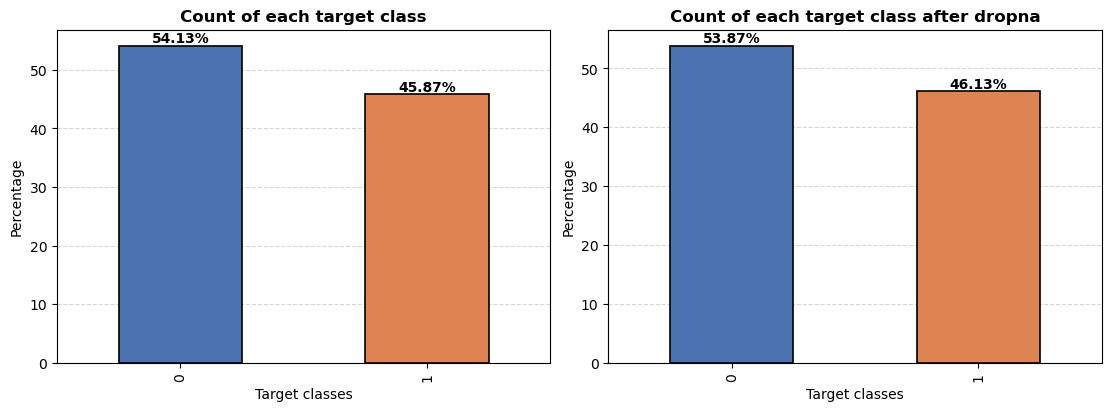

In [8]:
# Remove all rows containing missing values (NaN)
df_clean = df.dropna()

print(f"Original dataframe size (before dropna): {df.shape}")
print(f"Cleaned dataframe size (after dropna): {df_clean.shape}")

# Set up the subplot grid
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
datasets = [(df, 'Count of each target class'), (df_clean, 'Count of each target class after dropna')]

# Loop through datasets
for ax, (data, title) in zip(axes, datasets):
    # Compute relative class frequencies as percentages
    pct = data['target'].value_counts(normalize=True) * 100
    
   # Render bar plot 
    pct.plot.bar(ax=ax, color=sns.color_palette("deep").as_hex(), edgecolor='black', linewidth=1.2)
    
    # Labels and styling
    ax.bar_label(ax.containers[0], fmt='%.2f%%', fontweight='bold')
    ax.set(xlabel='Target classes', ylabel='Percentage')
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

plt.show()

* **Minimal Impact of `dropna`:** Removing rows with missing values (reducing the dataset from $303$ to $297$ observations) had practically no effect on the target variable distribution. The class ratio shifted by less than $0.3\%$.
  
* **Perfect Balance Maintained:** The dataset remains almost perfectly balanced with minimal skew. Consequently:
    * **No Class Rebalancing Required:** Techniques such as SMOTE, oversampling, or undersampling are unnecessary for this dataset.
    * **Metric Reliability:**
        * Due to this optimal class balance, the standard Accuracy (the proportion of correct predictions) will reliably and accurately reflect the true performance of the model
        * However, given the clinical nature of this task (predicting a disease), we will prioritize **Recall** (Sensitivity) and the **F1-score** to strictly minimize false negatives.

### Continuous Variables Analysis

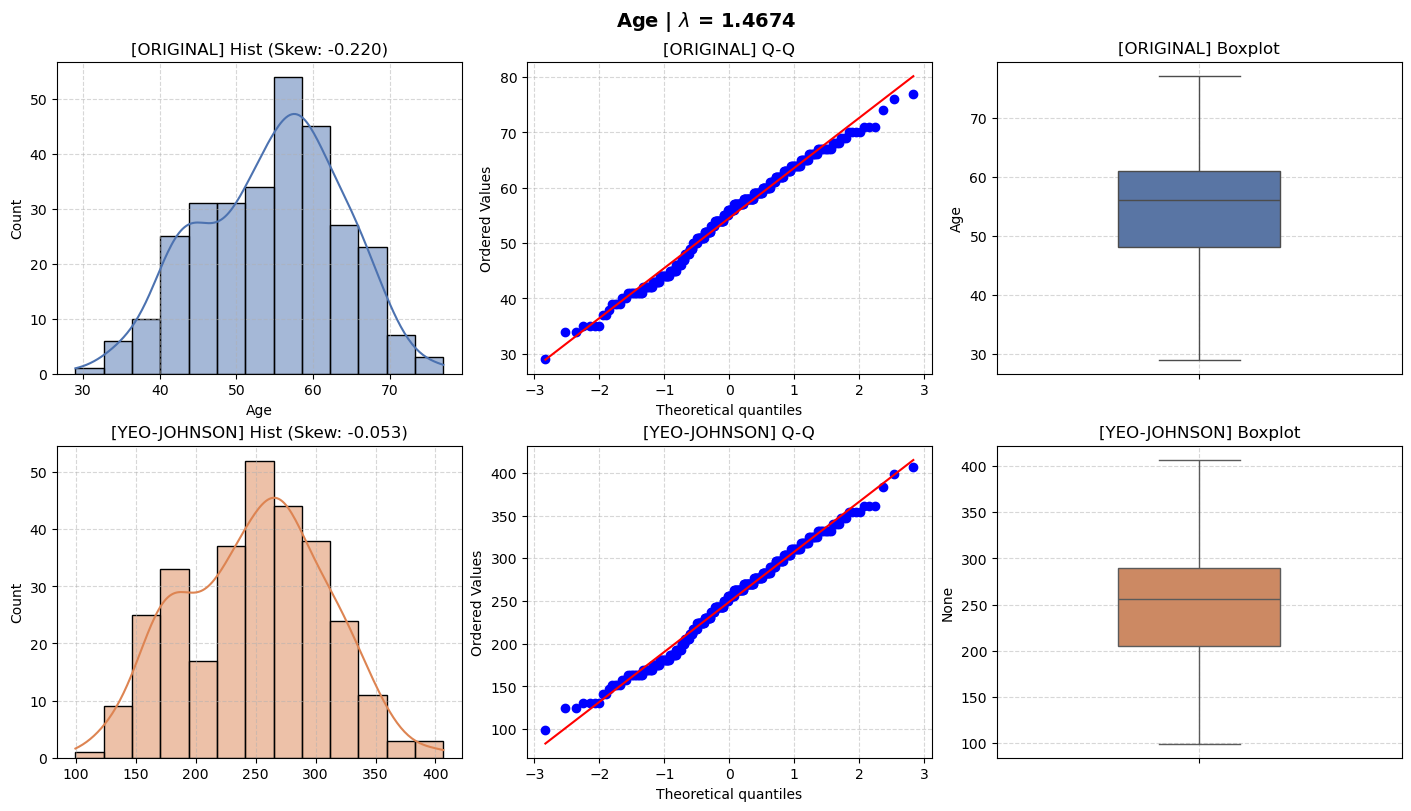

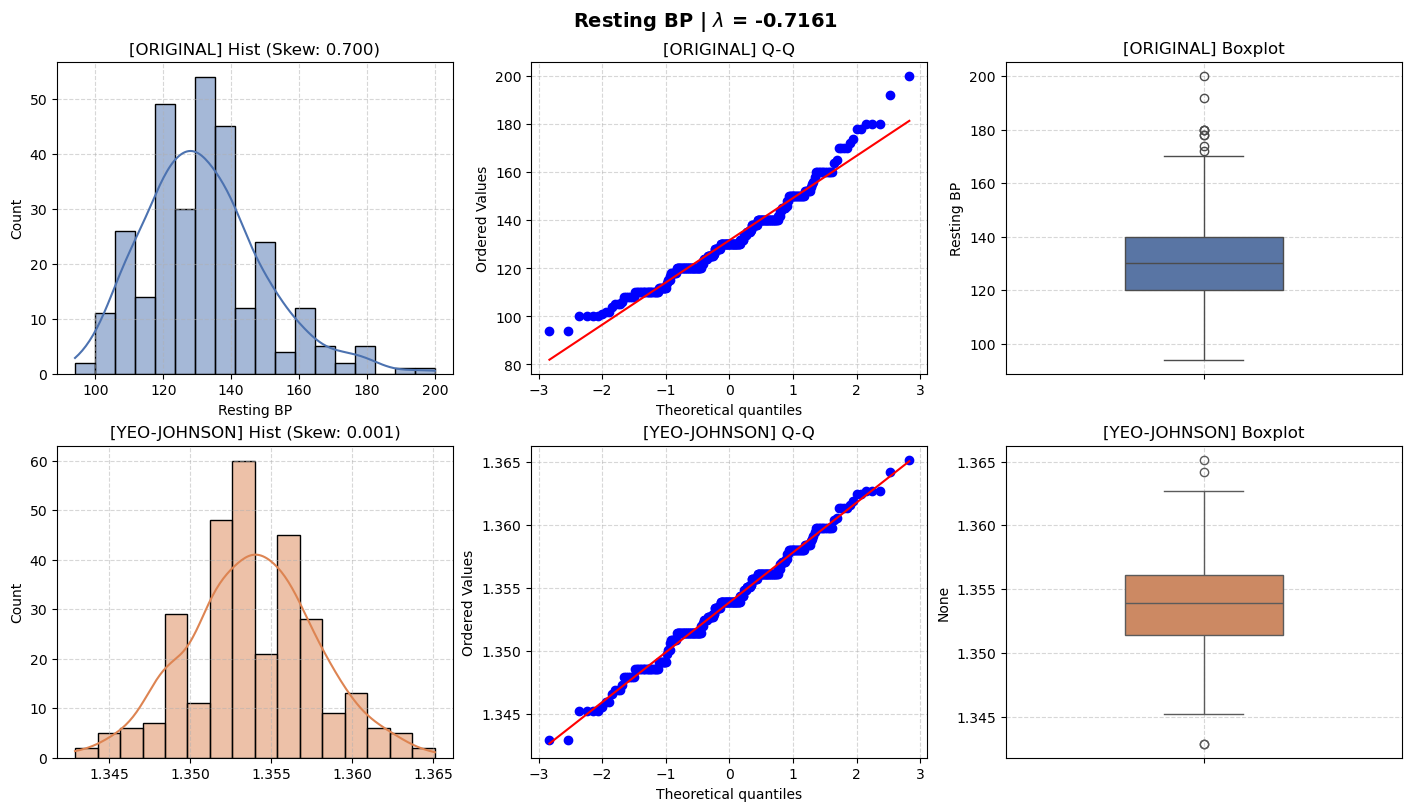

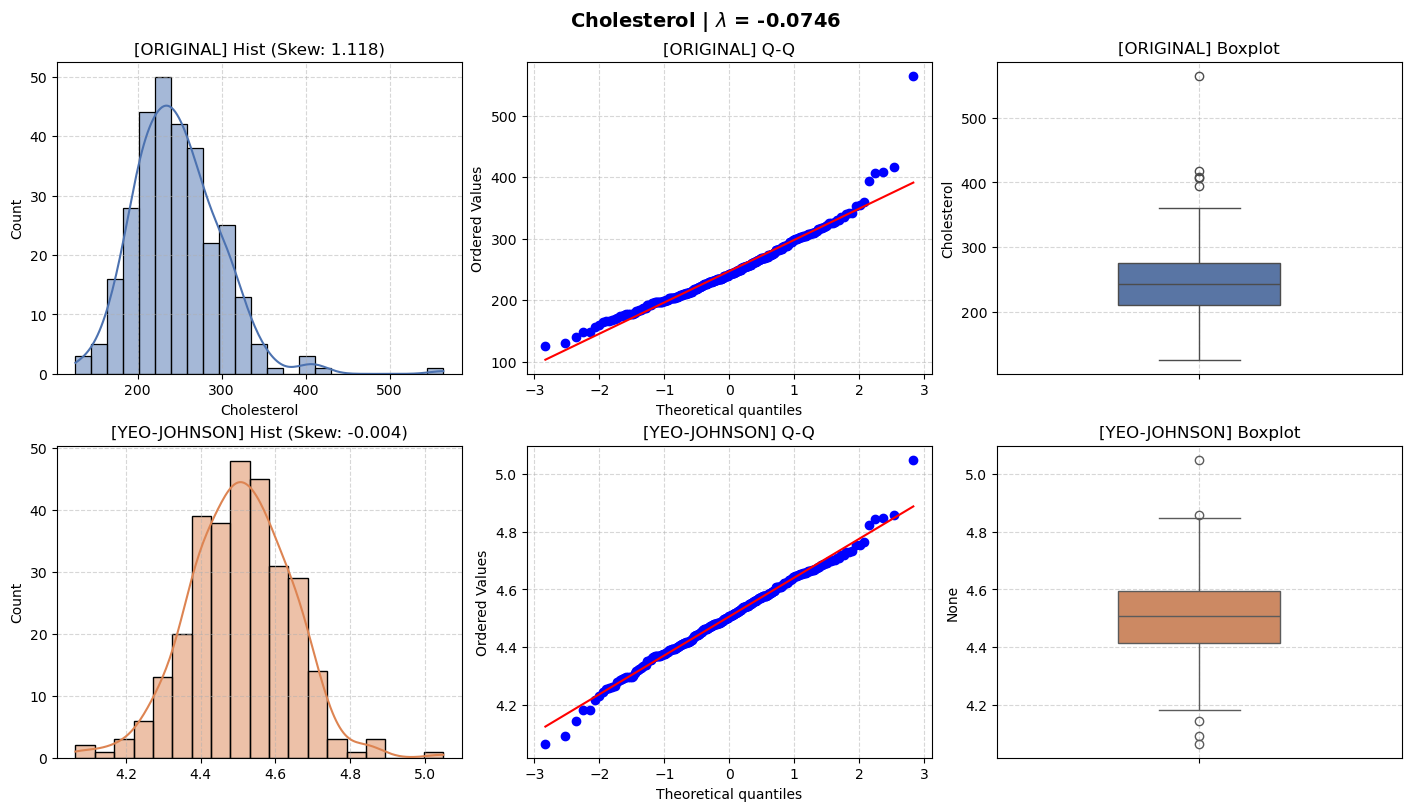

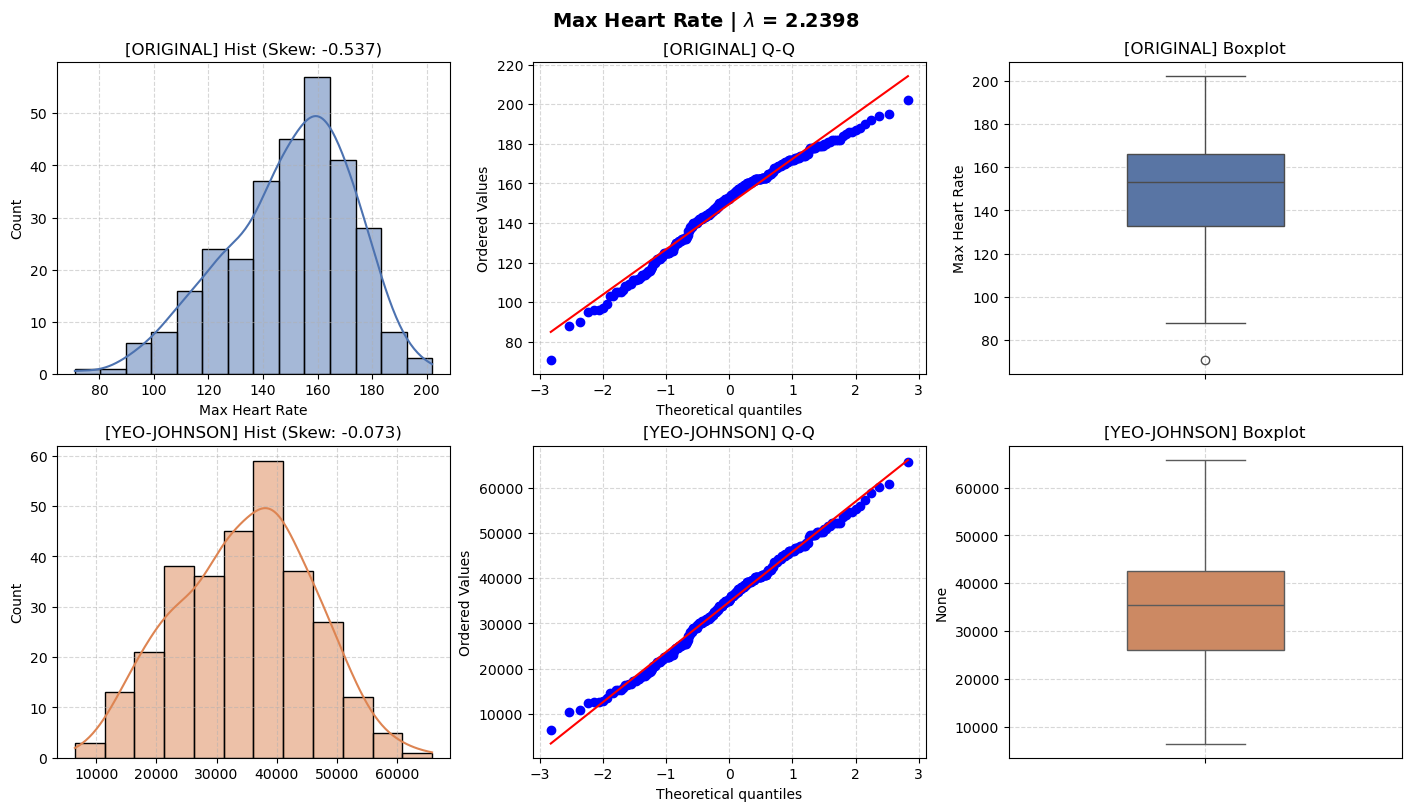

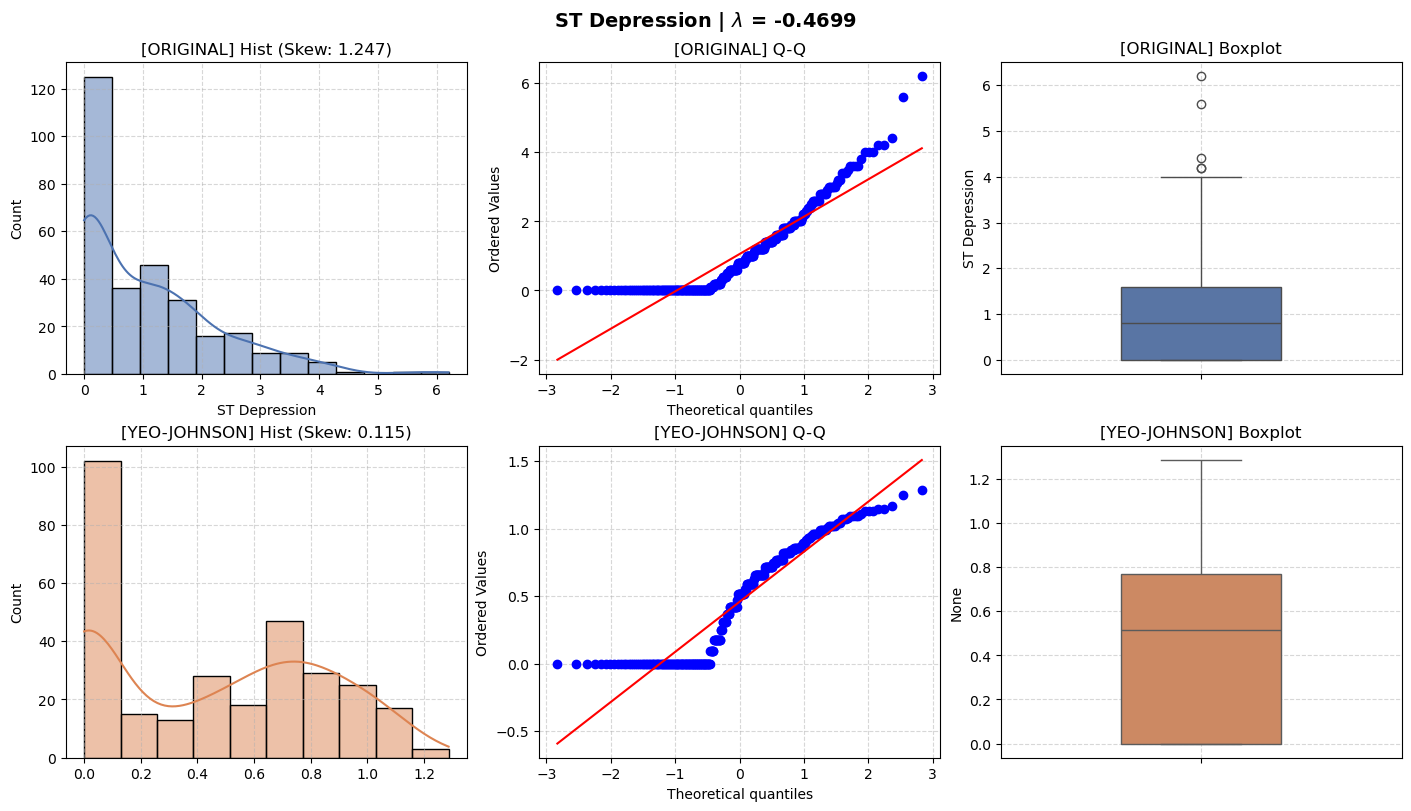

In [9]:
cat_cols = [col for col in df.columns if df[col].nunique() < 10 and col != 'target']
num_cols = [col for col in df.columns if col not in cat_cols and col != 'target']

df_transformed = transform_and_plot_yj(df_clean, num_cols)

**Age:**

* **Distribution:** Closest to a normal distribution (`skew = -0.22`).
* **Q-Q Plot:** Perfect alignment along the diagonal line.
* **Outliers:** None detected.
* **Conclusion:** Analysis-ready; no transformation required.

**Resting BP & Cholesterol:**

* **Distribution:** Right-skewed (positive skewness of **0.70 and 1.12** respectively).
* **Q-Q Plot:** Distinct upward deviation on the upper (right) tail.
* **Outliers:** Multiple outliers present on the right end of the distribution.
* **Conclusion:** These represent clinically expected deviations (patients with hypertension and hypercholesterolemia). They require outlier handling or robust preprocessing.

**Max Heart Rate:**

* **Distribution:** Left-skewed (negative skewness of **-0.54**). The distribution is shifted to the right, indicating most patients achieve a high peak heart rate.
* **Q-Q Plot:** Deviation visible at the lower (left) tail.
* **Outliers:** Isolated low values on the left side (heart rate of $70–80$ bpm under stress conditions).
* **Conclusion:** Highly specific to patients with cardiovascular pathologies. It might be beneficial to retain these lower outliers as a strong predictive signal.

**ST Depression:**

* **Distribution:** Severe right-skewness (**skew = 1.25**) with a heavily zero-inflated structure.
* **Outliers:** Long right tail with extreme values exceeding $4$ mm.
* **Conclusion:** A value of $0$ is the physiological norm for most healthy individuals. Any value above zero serves as a clinical indicator of potential ischemia. Because these right-tail outliers carry critical clinical weight, heavily transforming or removing them could degrade model performance.

---

#### Yeo-Johnson Transformation Results (Before vs. After)

**Overall Evaluation:**

* The Yeo-Johnson transformation proved highly effective for all continuous features. Skewness metrics across the board were minimized to values near zero ($|skew| \le 0.11$).

**Resting BP & Cholesterol:**

* **Skewness Dynamics:** Reduced from $0.70$ and $1.12$ down to $0.003$ and $-0.004$, respectively.
* **Effect:** Right tails and extreme outliers were successfully pulled toward the center. The Q-Q plots straightened out, aligning tightly with the diagonal baseline.

**Max Heart Rate:**

* **Skewness Dynamics:** Shifted from $-0.54$ to $0.07$.
* **Effect:** The left-side skewness was completely eliminated. The isolated lower outliers (pulse of $70–80$ bpm) were smoothly integrated into the left tail of the newly symmetric distribution.

**ST Depression:**

* **Skewness Dynamics:** Decreased from $1.25$ down to $0.115$.
* **Characteristics:** While the skewness statistic improved significantly, both the histogram and the Q-Q plot clearly highlight the underlying **zero-inflated** structure. The Q-Q plot displays a distinct horizontal plateau at the minimum value boundary.
* **Conclusion:** The transformation successfully compressed the long right tail—making extreme pathological depression values less isolated—while preserving the structurally essential cluster of patients with zero ST depression. The feature profile was optimized without discarding this vital discrete signal.

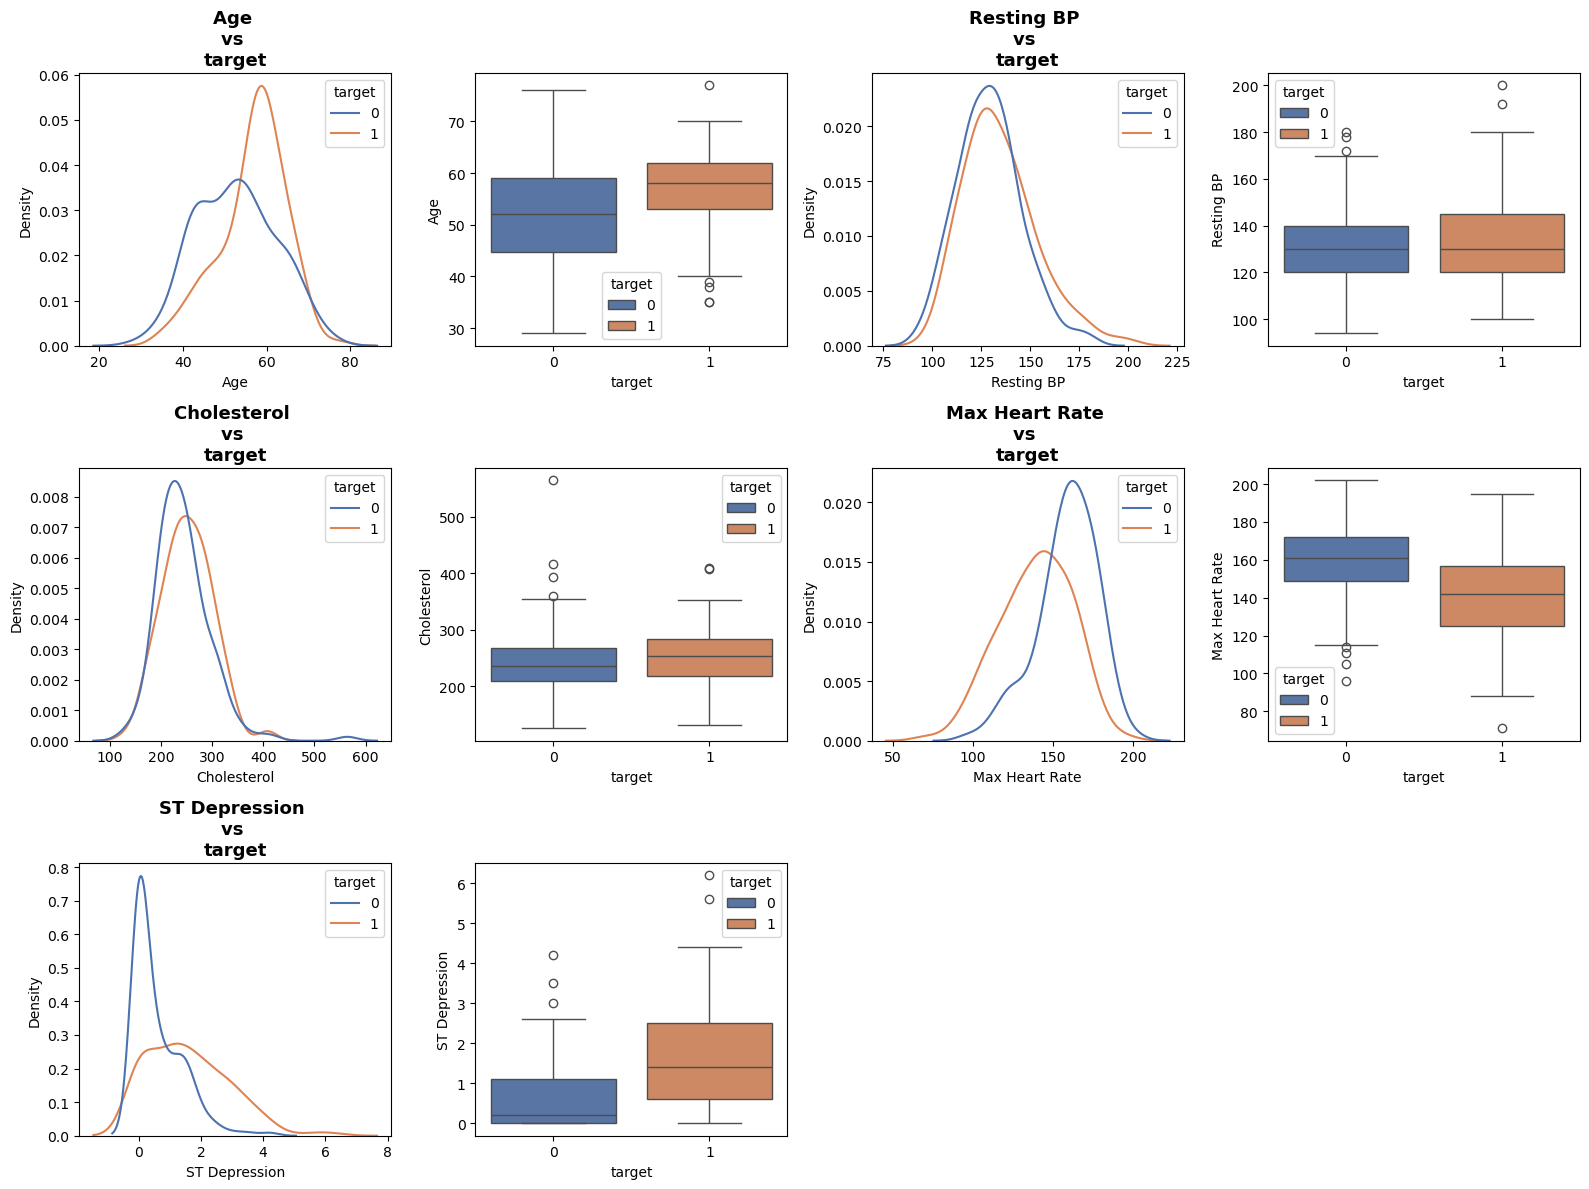

In [10]:
# Grid setup: 4 columns (2 plots for each feature: KDE + Boxplot)
n_rows = math.ceil(len(num_cols) / 2)
fig, axes = plt.subplots(n_rows, 4, figsize=(16, 4 * n_rows))
axes = axes.flatten()

# Plot distributions
for i, var in enumerate(num_cols):
    # Allocate axes for the current pair (KDE + Boxplot)
    ax1, ax2 = axes[i * 2], axes[i * 2 + 1]

    # Render plots
    sns.kdeplot(data=df_clean, x=var, hue='target', common_norm=False, ax=ax1, palette='deep')
    sns.boxplot(data=df_clean, x='target', y=var, hue="target", palette='deep', ax=ax2)

    # Set title above the left plot
    ax1.set_title(f'{var} \nvs \ntarget', fontsize=13, fontweight='bold')

# Cleanup unused axes 
for i in range(len(num_cols) * 2, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

#### Relationship of Continuous Features with the Target Variable (`target`)

**High Separability (Strong Predictive Power):**

* **ST Depression:** This feature demonstrates the most pronounced class segregation. Healthy individuals are heavily concentrated around the zero mark. A rightward shift in the distribution (the presence of ST segment depression) strongly signals a high probability of pathology.
* **Max Heart Rate:** There is a distinct inter-class divergence here. Patients with heart disease exhibit a significantly lower median maximum heart rate under exertion compared to healthy individuals.

**Weak Separability:**

* **Age:** The kernel density estimate (KDE) plots overlap heavily. While the `target=1` group features a slightly younger median age and a sharper peak within this cohort, this variable alone does not provide a reliable boundary for class separation.

**No Separability (Noise / Non-Predictive):**

* **Resting BP & Cholesterol:** There is a complete alignment of the density graphs (KDE) and nearly identical boxplots across both classes. The medians, extremes, and interquartile ranges (IQR) for healthy and diseased patients are practically indistinguishable. Consequently, these metrics are highly ineffective as standalone predictors for linear decision boundaries.

### Categorical Variables Analysis

In [11]:
# Replace encoded categories with human-readable labels 
df_mapped = df_clean.replace(value_maps)  

df_mapped.head()

,Age,Sex,Chest Pain,Resting BP,Cholesterol,Blood Sugar >120,Resting ECG,Max Heart Rate,Exercise Angina,ST Depression,ST Slope,Diseased Vessels,Thallium Test,target
0,63.0,Male,Typical,145.0,233.0,Yes,LVH,150.0,No,2.3,Downsloping,0.0,Fixed,0
1,67.0,Male,Asymptomatic,160.0,286.0,No,LVH,108.0,Yes,1.5,Flat,3.0,Normal,1
2,67.0,Male,Asymptomatic,120.0,229.0,No,LVH,129.0,Yes,2.6,Flat,2.0,Reversible,1
3,37.0,Male,Non-Anginal,130.0,250.0,No,Normal,187.0,No,3.5,Downsloping,0.0,Normal,0
4,41.0,Female,Atypical,130.0,204.0,No,LVH,172.0,No,1.4,Upsloping,0.0,Normal,0


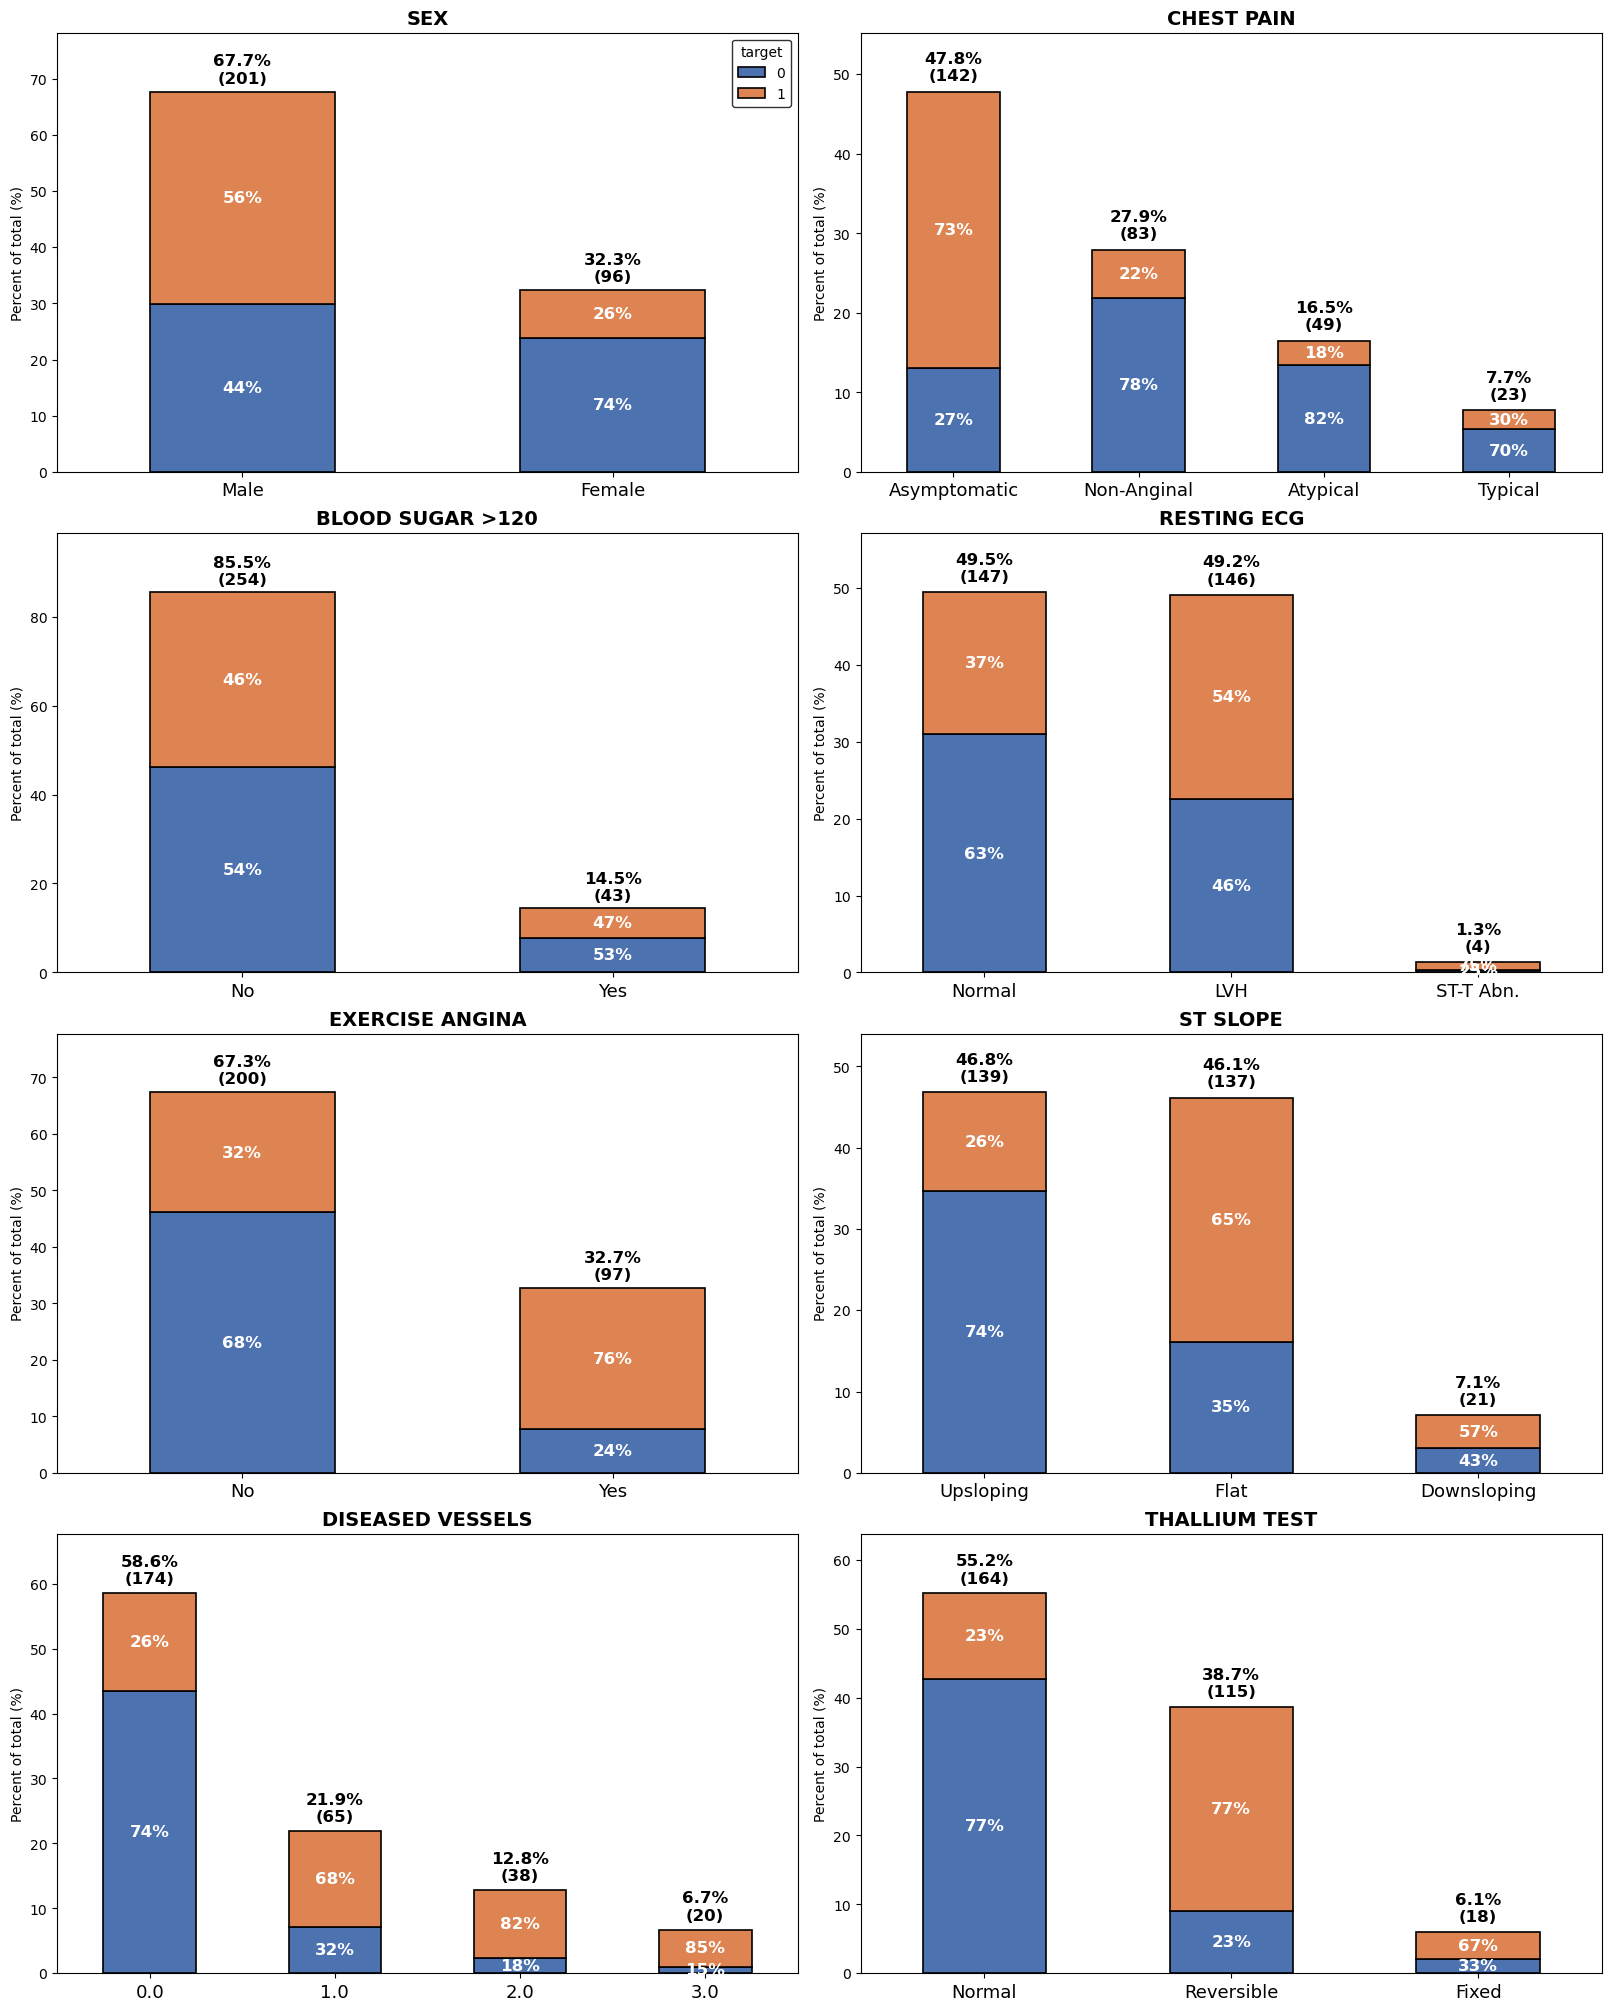

In [12]:
analyze_categorical_features(df_mapped, cat_cols, target='target', n_cols=2)

**Primary Pathological Markers (High Risk / `target=1`):**

* **Chest Pain Type:**
    * The most critical category is **asymptomatic** presentation, where $73\%$ of patients are diseased.
    * *Clinical Insight:* Patients without pronounced pain symptoms are likely unaware of the issue, leading them to seek medical attention at much later stages when the disease is already advanced.


* **ST Slope:**
    * A **flat** slope is strongly associated with high risk ($65\%$ of patients are diseased).
    * *Clinical Insight:* Since the ECG is recorded during a stress test (under physical exertion), a normal ST segment should be **upsloping** (where $74\%$ of patients are healthy). A flat dynamic under load is a classic clinical indicator of ischemia.


* **Number of Diseased Vessels:**
    * This is the most linear predictor.
    * Patients with $0$ major vessels colored have a disease risk of only $26\%$.
    * However, as pathology appears in $1$, $2$, or $3$ vessels, the probability of disease surges to $68\%$, $82\%$, and $85\%$, respectively.


* **Thallium Stress Test:** The presence of a **reversible defect** is a powerful indicator of pathology ($77\%$ diseased).
* **Exercise-Induced Angina:** Angina triggered by physical exertion (`yes`) is a textbook symptom, confirming a high risk profile ($76\%$ diseased).

**Secondary Risk Factors:**

* **Sex:** In this cohort, males exhibit a significantly higher risk of heart disease ($56\%$ diseased), whereas females predominantly skew healthy ($74\%$ healthy).

**Noise / Non-Predictive Features:**

* **Fasting Blood Sugar:**
    * The disease risk hovers at $46–47\%$ regardless of whether fasting blood sugar exceeds the baseline threshold ($>120$ mg/dL) or not.
    * This feature yields no meaningful predictive power for the model.

### Features vs. Chest Pain (Cross-Analysis)

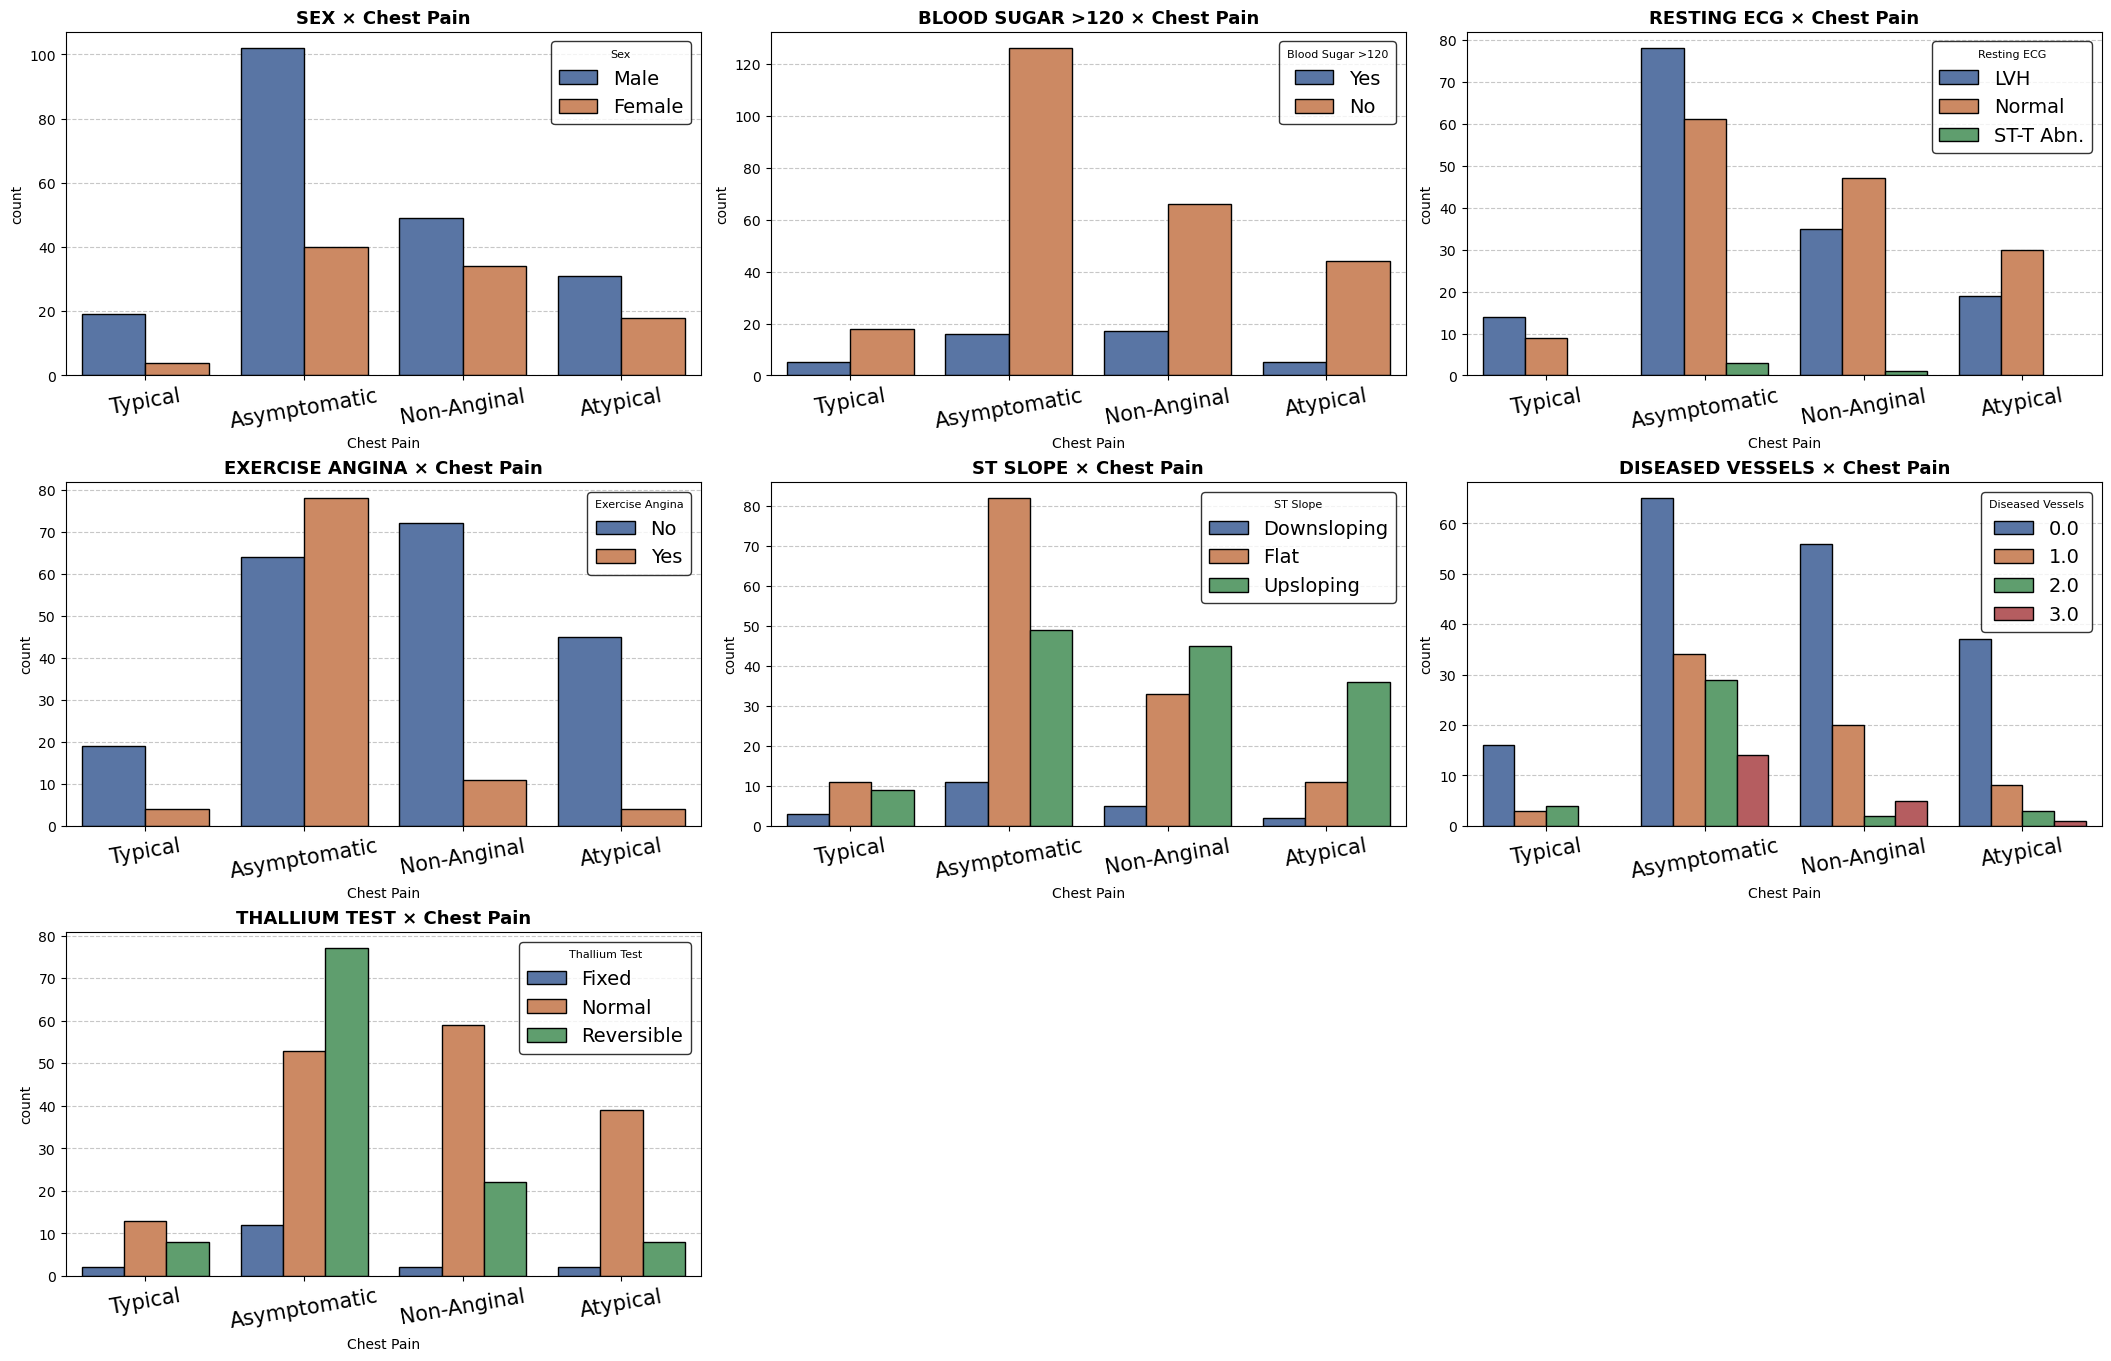

In [13]:
plot_features_vs_target(df_mapped, [c for c in cat_cols if c != 'Chest Pain'])

#### Relationship of Features with Chest Pain Type

* `Exercise-induced angina`: Exercise-induced angina (`yes`) occurs *almost exclusively* within the asymptomatic cohort. For typical, atypical, and non-anginal pain types, the vast majority of patients do not experience it (`no`).
* `Thallium stress test result`: The presence of a reversible defect (`revers.defect`) is the dominant outcome only for `asymptomatic` patients. In all other chest pain groups, the overwhelming majority exhibit normal results.
* `Peak Exercise ST Slope`: The pathological **flat** slope heavily prevails within the asymptomatic group. Conversely, other chest pain types are characterized by a healthy **upsloping** trend.

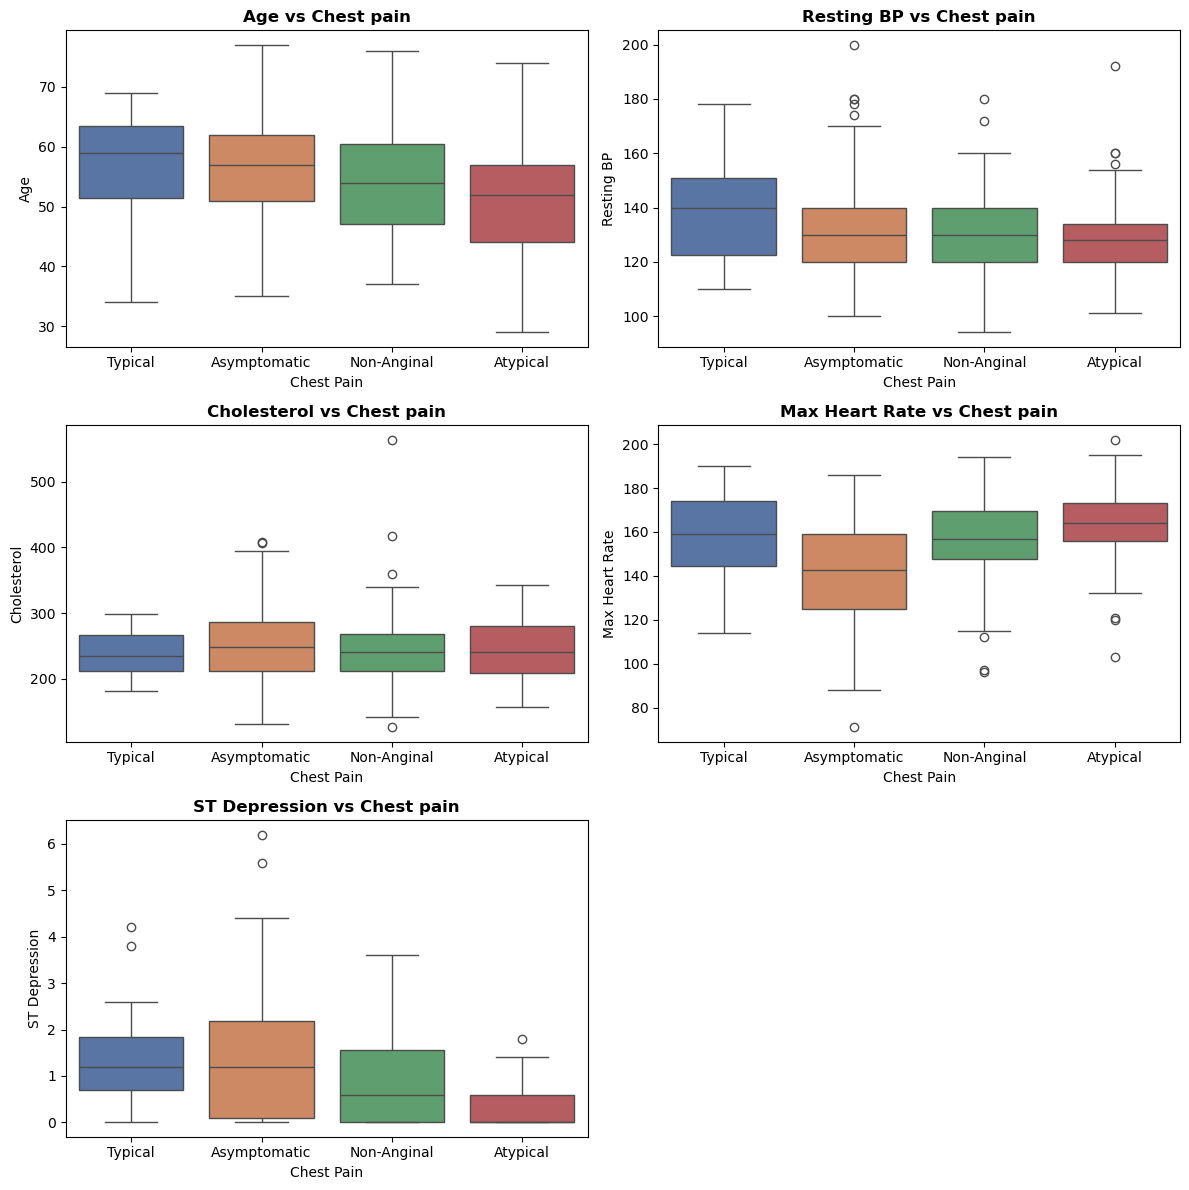

In [14]:
n_cols = 2
n_rows = math.ceil(len(num_cols) / n_cols)

# Create the subplot grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, var in enumerate(num_cols):
    sns.boxplot(data=df_mapped, x='Chest Pain', y=var, hue='Chest Pain', palette='deep', ax=axes[i])
    axes[i].set_title(f'{var} vs Chest pain', fontweight='bold')

# Remove empty subplots 
for i in range(len(num_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

#### Risk Factors Across Chest Pain Types

**High Separability (Strong Differentiation):**

* `Max Heart Rate`: Patients in the `Asymptomatic` cohort exhibit a significantly lower median maximum heart rate under exertion ($142$ bpm) compared to all other chest pain groups ($>155$ bpm).
* `ST Depression`: A pronounced upward shift in the median and an abundance of extreme outliers (up to $6$ mm) are observed exclusively within the `Asymptomatic` group. For patients with typical or atypical angina, values remain heavily clustered around zero.

**No Differentiation (Non-Predictive Patterns):**

* `Age`: The interquartile ranges (IQRs) on the boxplots heavily overlap across all four groups, with medians constrained within a narrow window of $52–57$ years. This indicates that the specific character of chest pain is poorly dependent on age within this cohort.
* `Resting BP` & `Cholesterol`: The medians (approximately $130$ mm Hg and $240$ mg/dL, respectively) and the span of the whiskers remain virtually identical regardless of the chest pain type.

### Feature Correlations & Interactions

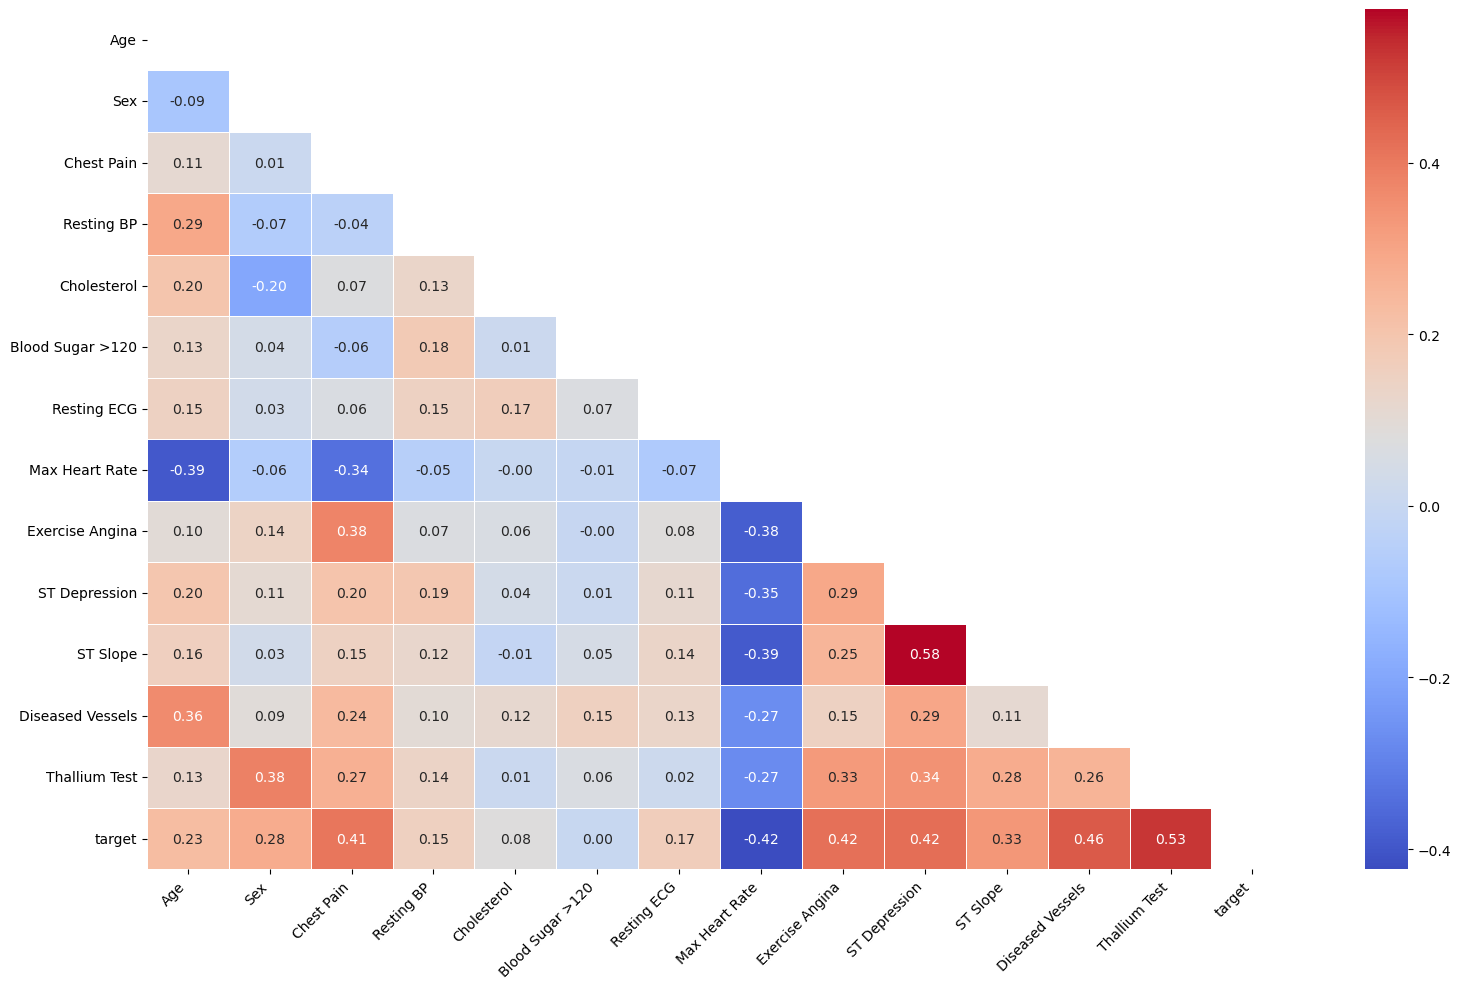

In [15]:
plt.figure(figsize=(16, 10))
sns.heatmap(df_clean.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, mask=np.triu(np.ones_like(df_clean.corr(), dtype=bool)))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Pearson Correlation

**Relationship with the Target Variable (`target`)**

* **Strong Risk Markers (Direct Correlation):**
    * `Thallium Test` ($0.53$) and `Diseased Vessels` ($0.46$) exhibit the strongest linear correlation.
    * `Exercise Angina` ($0.43$), `ST Depression` ($0.42$), and `Chest Pain` ($0.41$) also demonstrate a consistently high impact.

* **Strongest Negative Correlation:** `Max Heart Rate` ($-0.42$) — the heart's ability to achieve a high maximum heart rate during exercise is associated with the absence of the disease.
* **Zero Impact:** Linear correlation for `Blood Sugar >120` ($0.03$) and `Cholesterol` ($0.09$) with the target is practically non-existent.

**Multicollinearity (Inter-feature Relationships)**

* The matrix lacks critical values (close to $1$ or $-1$) among the independent variables.
* The maximum correlation coefficient does not exceed $0.58$.

**Logical Physiological Patterns**

* **ECG Metrics:** The most pronounced correlation among predictors is observed between `ST Slope` and `ST Depression` ($0.58$). Both features characterize the deformation of the same ECG segment.
* **Age-related Changes:** Age (`Age`) demonstrates an expected inverse relationship with the maximum heart rate (`Max Heart Rate`, $-0.39$).
* **Exercise Tolerance:** `Max Heart Rate` shows a distinct negative correlation with exercise-induced angina (`Exercise Angina`, $-0.38$) and ECG abnormalities (`ST Slope`, $-0.39$) — the poorer the exercise tolerance, the lower the maximum heart rate.

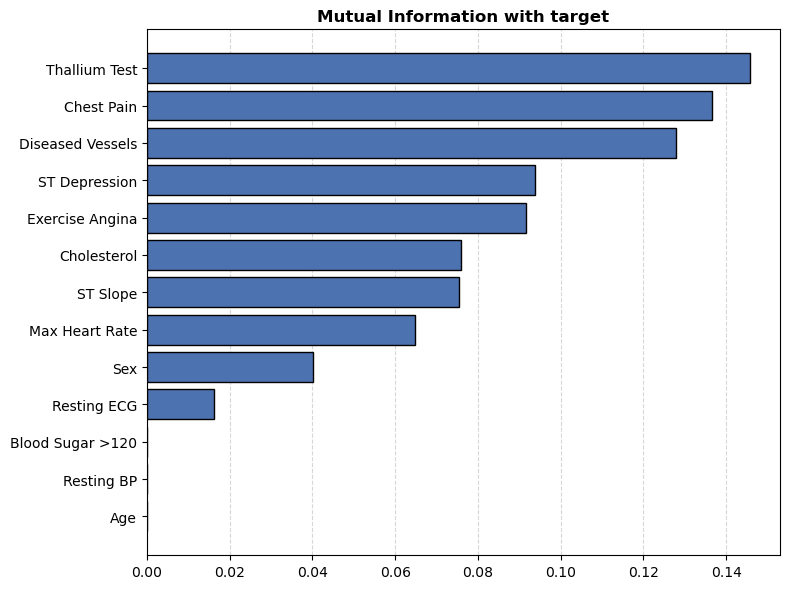

In [16]:
X = df_clean.drop(columns=['target'])
y = df_clean['target']

# Boolean mask for discrete features
is_discrete = X.nunique() < 10

# Compute Mutual Information (MI) scores and sort them
mi_scores = pd.Series(mutual_info_classif(X, y, discrete_features=is_discrete, random_state=0), index=X.columns).sort_values()

# Plot the horizontal bar chart 
plt.figure(figsize=(8, 6)) 
plt.barh(mi_scores.index, mi_scores.values, edgecolor='black', color='#4C72B0')
plt.title("Mutual Information with target", fontweight='bold')
plt.gca().set_axisbelow(True)
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Mutual Information

* **Most Informative Features:** `Thallium Test` ($0.14$), `Chest Pain` ($0.13$), and `Diseased Vessels` ($0.12$). These metrics capture the highest amount of information necessary to determine whether a patient is diseased or healthy.

* `Cholesterol` Breakdown:
    * Based on the previous correlation heatmap, its linear relationship with the target was near zero.
    * However, the Mutual Information (MI) metric yields a score of approximately $0.075$.
    * This confirms that a relationship between cholesterol and the target variable exists, but it is distinctly non-linear.

* **Low Informative Value:** The `Blood Sugar >120` feature exhibits an extremely low score across both Mutual Information and linear correlation metrics, indicating negligible predictive power.

### Multidimensional Feature Spaces

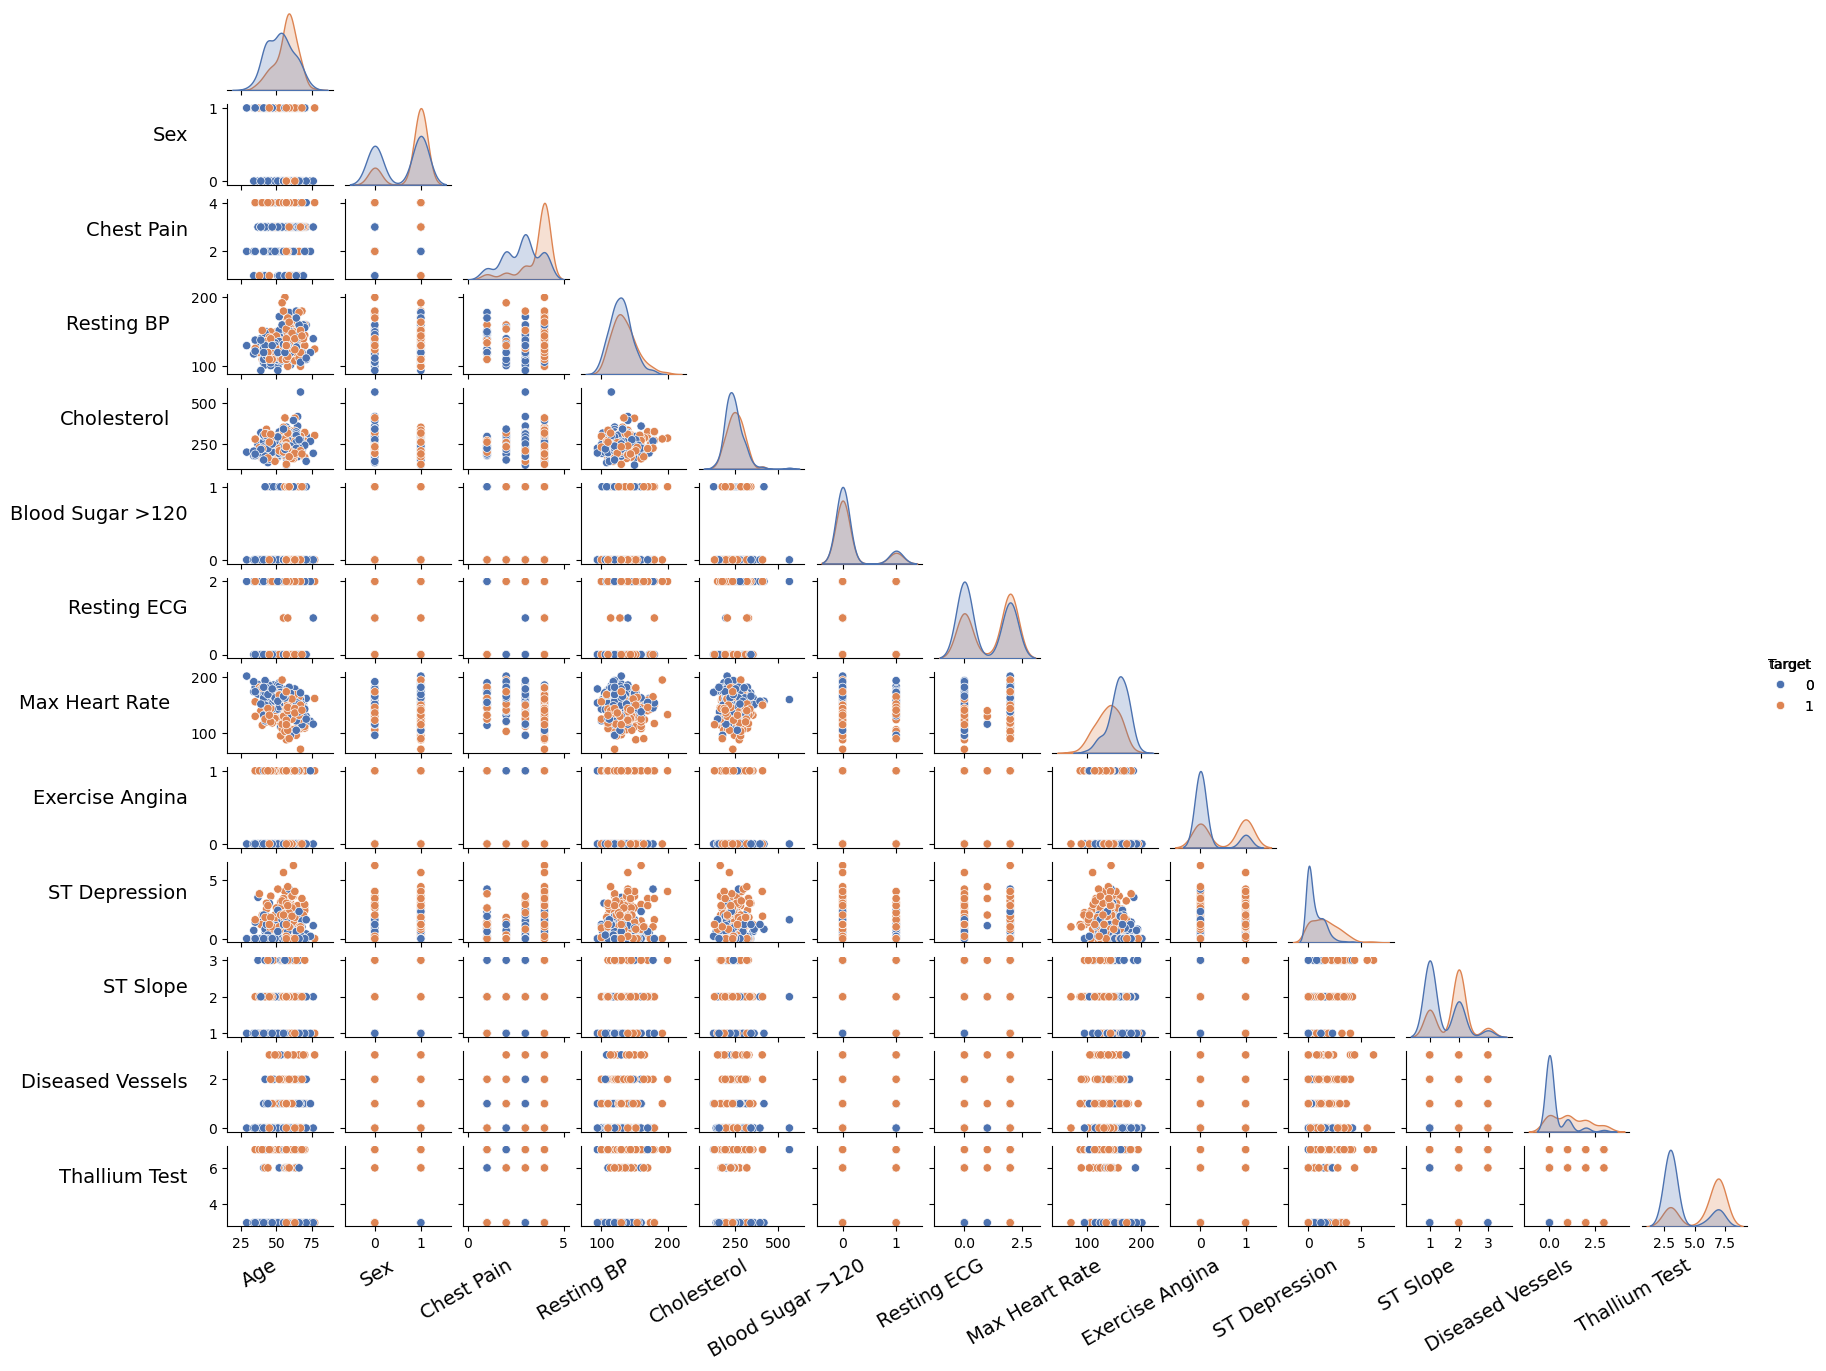

In [17]:
g = sns.pairplot(data=df_clean, hue="target", corner=True, palette='deep', height=1, aspect=1.2)
g.add_legend(title="Target")

# Iterate through all subplots in the grid
for ax in g.axes.flatten():
    if ax is not None:
        # Rotate and scale X-axis variable labels for better readability
        if ax.get_xlabel():
            ax.set_xlabel(ax.get_xlabel(), fontsize=14, rotation=30, ha='right')
        
        # Scale and align Y-axis variable labels
        if ax.get_ylabel():
            ax.set_ylabel(ax.get_ylabel(), fontsize=14, rotation=0, ha='right', labelpad=15)

plt.show()

#### Pairplot Analysis (hue="target")

**Diagonal Plots (Feature Distributions):**

* `Chest Pain`, `Max Heart Rate`, `Exercise Angina`, and `ST Depression` exhibit strong predictive power, as their blue and orange density plots show significant separation from each other.
* For features like `Age`, `Resting BP` (blood pressure), and `Cholesterol`, the density plots for both classes overlap almost entirely. This indicates that it is impossible to separate healthy and diseased patients based on age or blood pressure alone.

**Off-Diagonal Plots (Feature Interactions):**

* At the intersections of key features (for example, plotting `Max Heart Rate` against `ST Depression` or `Chest Pain`), distinct clusters form, with blue and orange points grouping in different regions of the coordinate plane.
* The scatter plot for `Age` and `Max Heart Rate` displays a clearly visible downward-sloping cloud of points, visually confirming their negative correlation (maximum heart rate declines as age increases).

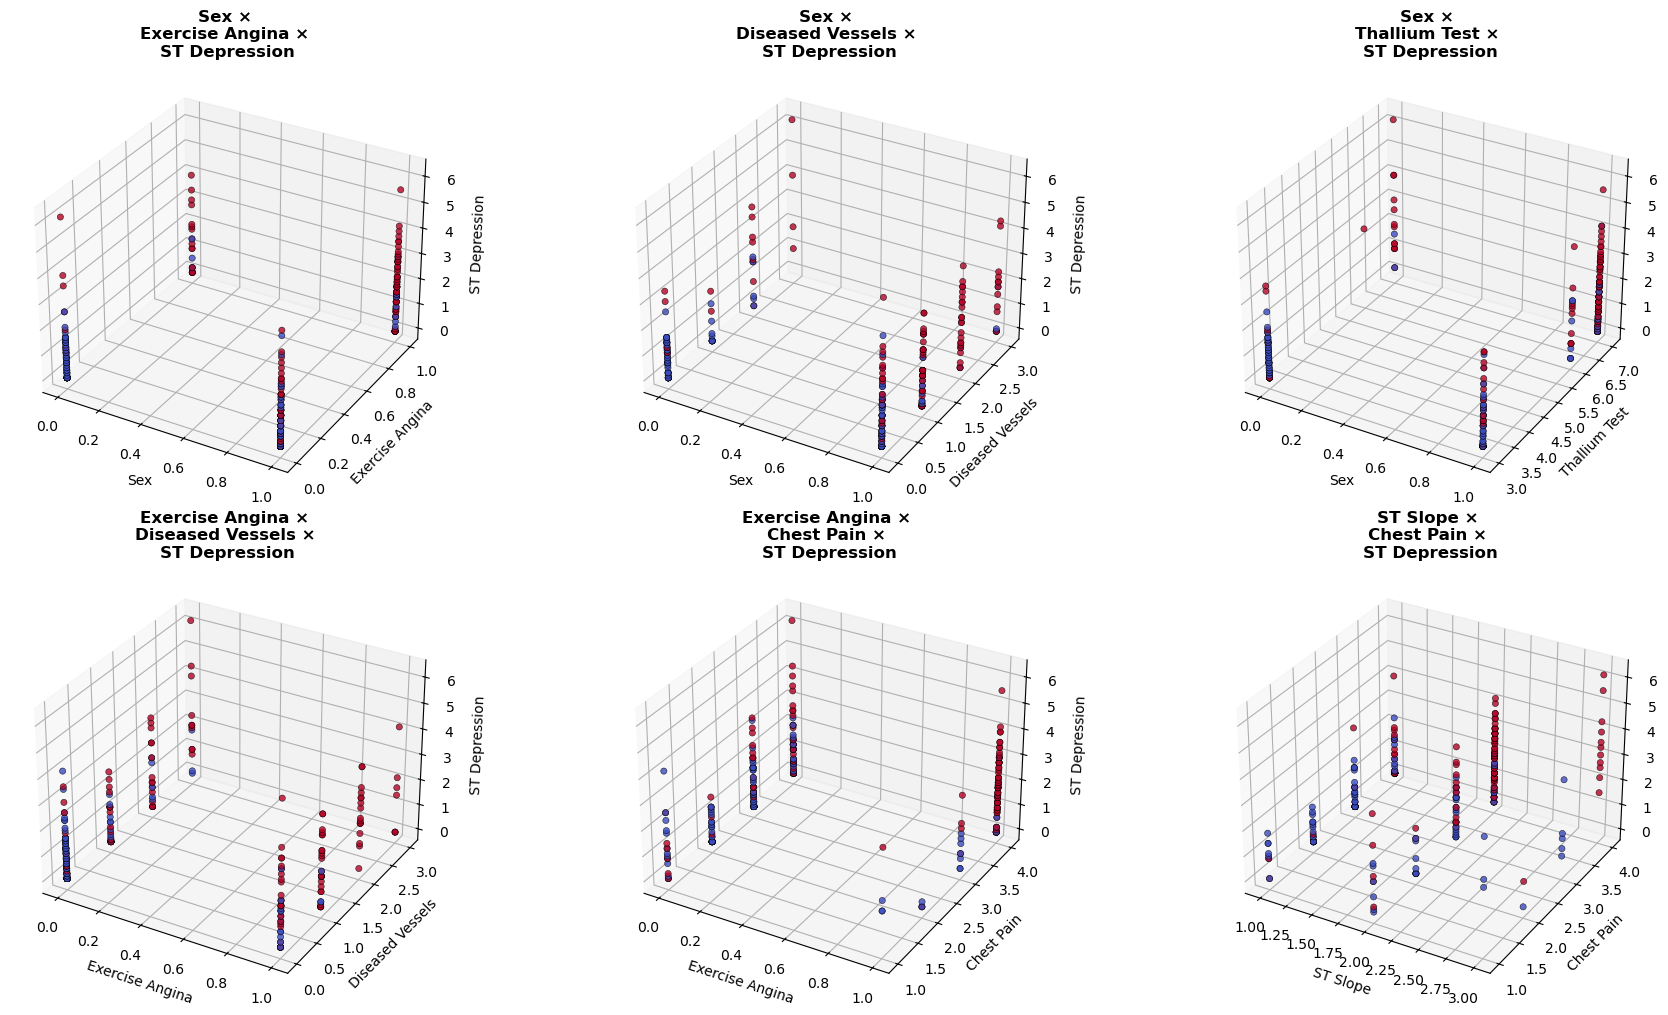

In [18]:
triples = [
    ('Sex', 'Exercise Angina', 'ST Depression'),
    ('Sex', 'Diseased Vessels', 'ST Depression'),
    ('Sex', 'Thallium Test', 'ST Depression'),
    ('Exercise Angina', 'Diseased Vessels', 'ST Depression'),
    ('Exercise Angina', 'Chest Pain', 'ST Depression'),
    ('ST Slope', 'Chest Pain', 'ST Depression')
]

# Set up a grid with 3 plots per row
n_rows = math.ceil(len(triples) / 3)
fig, axes = plt.subplots(
    n_rows, 3, 
    figsize=(18, 5 * n_rows), 
    subplot_kw={'projection': '3d'},
    constrained_layout=True
)

# Render plots
for ax, (x, y, z) in zip(axes.flat, triples):

    # Plot 3D scatter
    ax.scatter(
        df_clean[x], df_clean[y], df_clean[z], 
        c=df_clean['target'], cmap='coolwarm', 
        alpha=0.8, edgecolor='k', linewidth=0.4
    )

    # Set titles and axis labels
    ax.set_title(f"{x} × \n{y} × \n{z}", fontweight='bold', fontsize=12)
    ax.set(xlabel=x, ylabel=y, zlabel=z)
plt.show()

#### 3D Scatter Plot Analysis (hue="target")

**ST Depression as a Global Segregator (Z-Axis):**

* Across all $6$ subplots, the `ST Depression` axis serves as the vertical dimension. Regardless of the features mapped to the $X$ and $Y$ axes, the "lower tier" of the coordinate space (ST values close to zero) is predominantly occupied by blue points.
* Moving upward along the $Z$-axis transitions patients directly into the red high-risk zone.

**"Absolute Risk" Clusters:**

* The `Exercise Angina × Diseased Vessels × ST Depression` plot (bottom left) demonstrates near-perfect clustering. Patients who concurrently exhibit exercise-induced angina, at least one diseased vessel, and elevated ST depression form a dense, isolated "red" block where healthy outcomes (blue points) are entirely absent.
* A similarly rigid structure is visible in the `Thallium Test` plot (top right): the combination of thallium test abnormalities and high ST depression forms a cluster representing maximum (near-certain) risk.

**Sensitivity Threshold Reduction (Chest Pain & ST Slope):**

* In the plots on the bottom row, when looking at specific types of `Chest Pain` or a pathological `ST Slope`, red points begin to emerge even at much lower "floors" of ST depression.
* This implies that a pronounced subjective presentation (typical pain profile) or a poor stress test result renders even minor ECG abnormalities clinically dangerous.

**Gender Specifics:**

* The `Sex` axis indicates that the core mechanics of disease progression (where an increase in exertion-induced symptoms correlates with higher risk) remain consistent for both sexes.
* However, on the `Sex = 1.0` plane (the right side of each cube in the top row), the overall concentration of red points in high-risk zones is visually denser.

## Model-Based Analysis (via CatBoost)
### Training the Baseline Model

In [19]:
cat_cols.remove('Diseased Vessels')

X = df_mapped.drop('target', axis=1)
y = df_mapped['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

print(X_train.shape, X_test.shape)

model = CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1, verbose=0, random_seed=0)
model.fit(X_train, y_train, cat_features=cat_cols)

(207, 13) (90, 13)


### Feature Importance (SHAP & Permutation)

In [20]:
# PRELIMINARY CALCULATIONS 
# Compute Permutation Importance
perm_result = permutation_importance(model, X_train, y_train, n_repeats=30, scoring="roc_auc", random_state=0)

# Compute SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)
shap_interactions = explainer.shap_interaction_values(X_train)

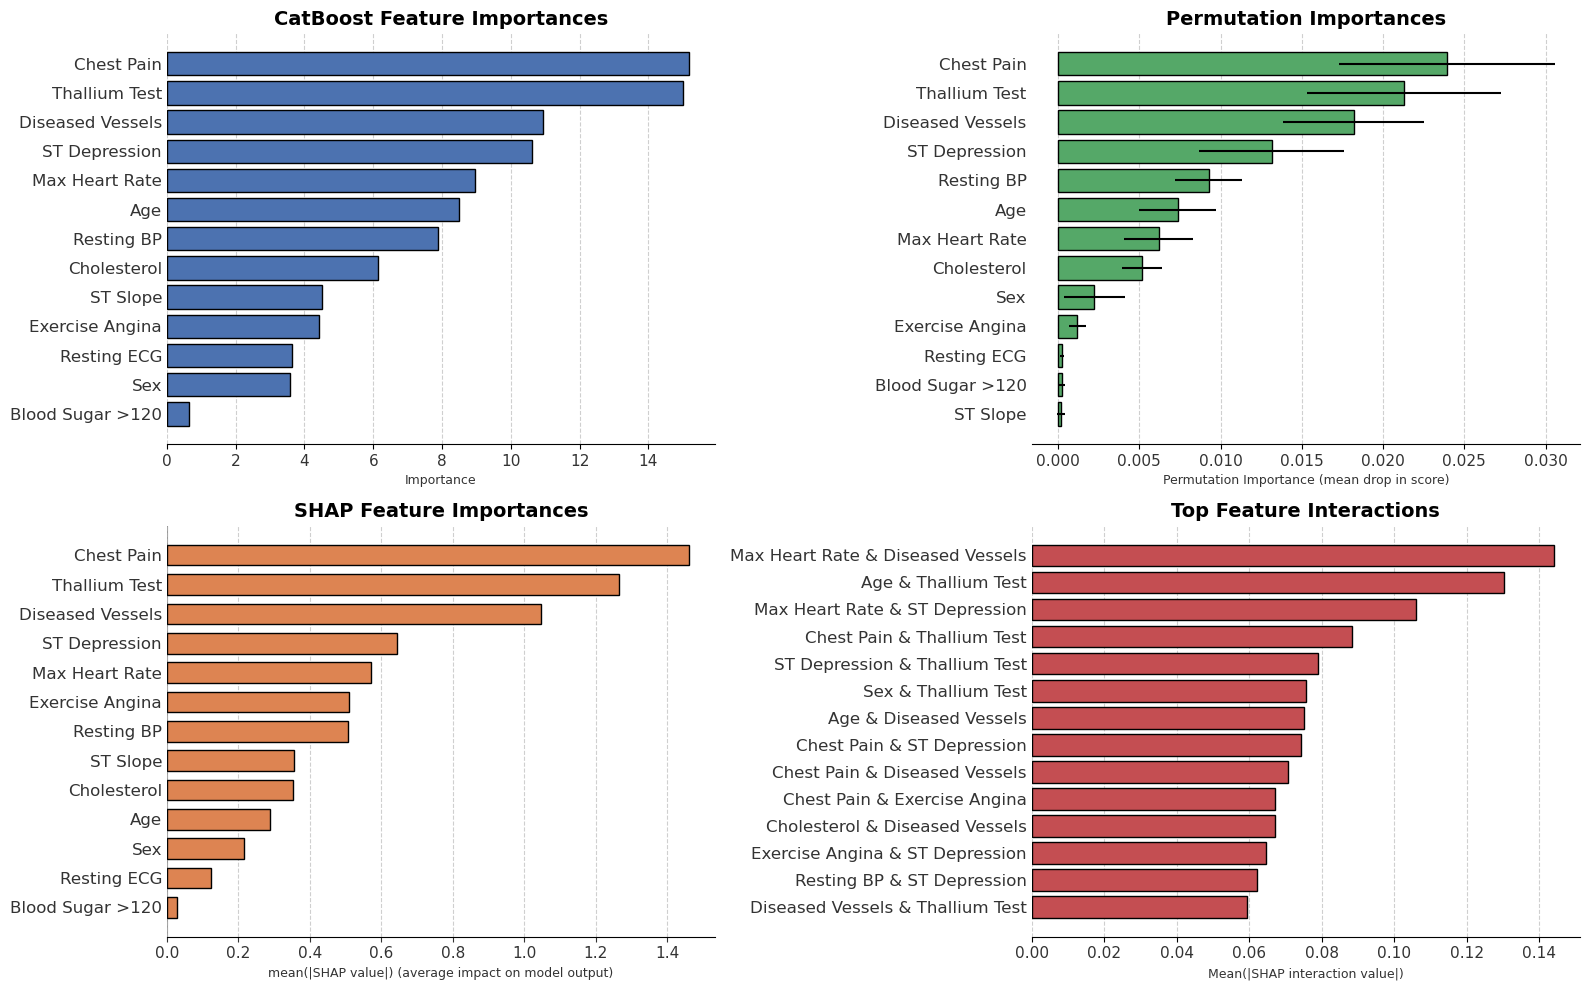

In [21]:
feature_importance_dashboard(model, X_train, shap_values, shap_interactions, perm_result)

**Dominant Predictors:**

* `Chest Pain` & `Thallium Test`: Primary markers of ischemic status.
* `Diseased Vessels` & `ST Depression`: Consistently rank within the top $4$ key features, demonstrating a high individual contribution to each patient's prediction.
* **Conclusion:** The combination of subjective presentation (pain character), functional testing (thallium), anatomical damage (number of stenosed vessels), and an ECG sign of hypoxia (`ST Depression`) forms a textbook diagnostic baseline in cardiology.

**Background & Secondary Predictors:**

* `Max Heart Rate` & `Age`: Show moderate but stable significance.
* `Cholesterol`: Holds a high weight in Permutation Importance (critical for global model accuracy) but demonstrates a low individual contribution on the SHAP summary plot.
* `Age` & `Resting BP`: Rank at the bottom of the importance lists across all charts.
* **Conclusion:** High blood pressure and cholesterol are long-term risk factors that create the conditions for pathology, but they possess weak standalone predictive power during active diagnosis.

**Top Interactions (Synergistic Effects):**

* `Max Heart Rate` & `Diseased Vessels`: A high heart rate under exertion becomes critical specifically under conditions of major artery stenosis.
* `Age` & `Thallium Test`: The second most significant interaction. It reflects a cumulative effect: over time, latent myocardial defects become more extensive and life-threatening.

### Model Interpretation (Partial Dependence)
#### 1D Partial Dependence (Individual Risk Thresholds)

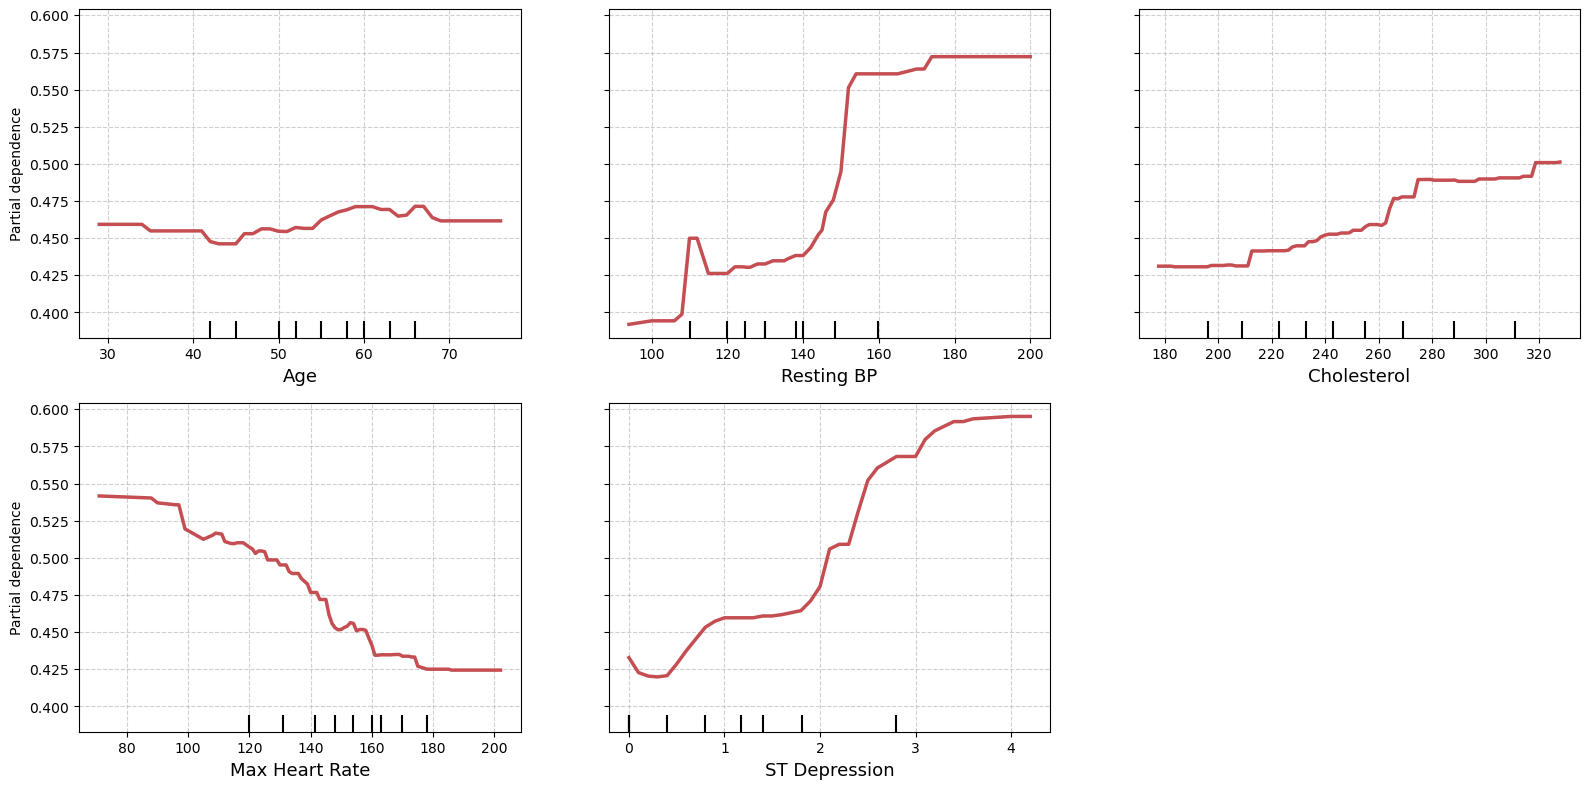

In [22]:
numeric_features = [
    'Age', 
    'Resting BP', 
    'Cholesterol', 
    'Max Heart Rate', 
    'ST Depression'
]

# Set up the subplot grid based on the number of numerical features
n_cols = 3
n_rows = math.ceil(len(numeric_features) / n_cols)
fig, ax = plt.subplots(figsize=(16, 4 * n_rows))

# Build 1D Partial Dependence Plots (1D PDP)
display = PartialDependenceDisplay.from_estimator(
    estimator=model,
    X=X_train,
    features=numeric_features,
    response_method="predict_proba",
    n_cols=n_cols,
    ax=ax,
    line_kw={"color": "#C44E52", "linewidth": 2.5}
)

# Adjust label sizes and enable background grids
for axi in display.axes_.flatten():
    if axi is not None:
        axi.set_xlabel(axi.get_xlabel(), fontsize=13)
        axi.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

* **Age:** CAD (Coronary Artery Disease) risk remains stable until age 40, followed by a pronounced, step-like increase within a narrow window of 52–58 years. For the 60+ cohort, the probability levels off at a maximum plateau.
* **Resting BP (Resting Blood Pressure):** Two distinct thresholds are observed. The first local risk jump occurs at a BP of 105–110 mm Hg. The critical threshold is **140 mm Hg**, beyond which the probability of CAD climbs sharply, peaking around 160 mm Hg.
* **Cholesterol:** Demonstrates a step-wise increase in risk. The probability of the disease begins to rise at a baseline value of 200 mg/dL and continues to climb up to 280 mg/dL.
* **Max Heart Rate:** This is the only feature displaying an **inverse relationship**. A low maximum heart rate (especially <100 bpm) is strongly associated with a high risk of CAD. Conversely, the capacity to achieve a peak heart rate >140 and >160 bpm is linked to a steep decline in the probability of having the disease.
* **ST Depression:** This stands out as the strongest direct risk indicator. The first trigger occurs at minimal deviation levels (>0.5 mm). Starting from the **1.8 mm** mark, a step-wise surge in CAD probability is observed, reaching its absolute maximum at values around 3.5 mm.

#### 2D Partial Dependence (Synergistic Risk Factors)

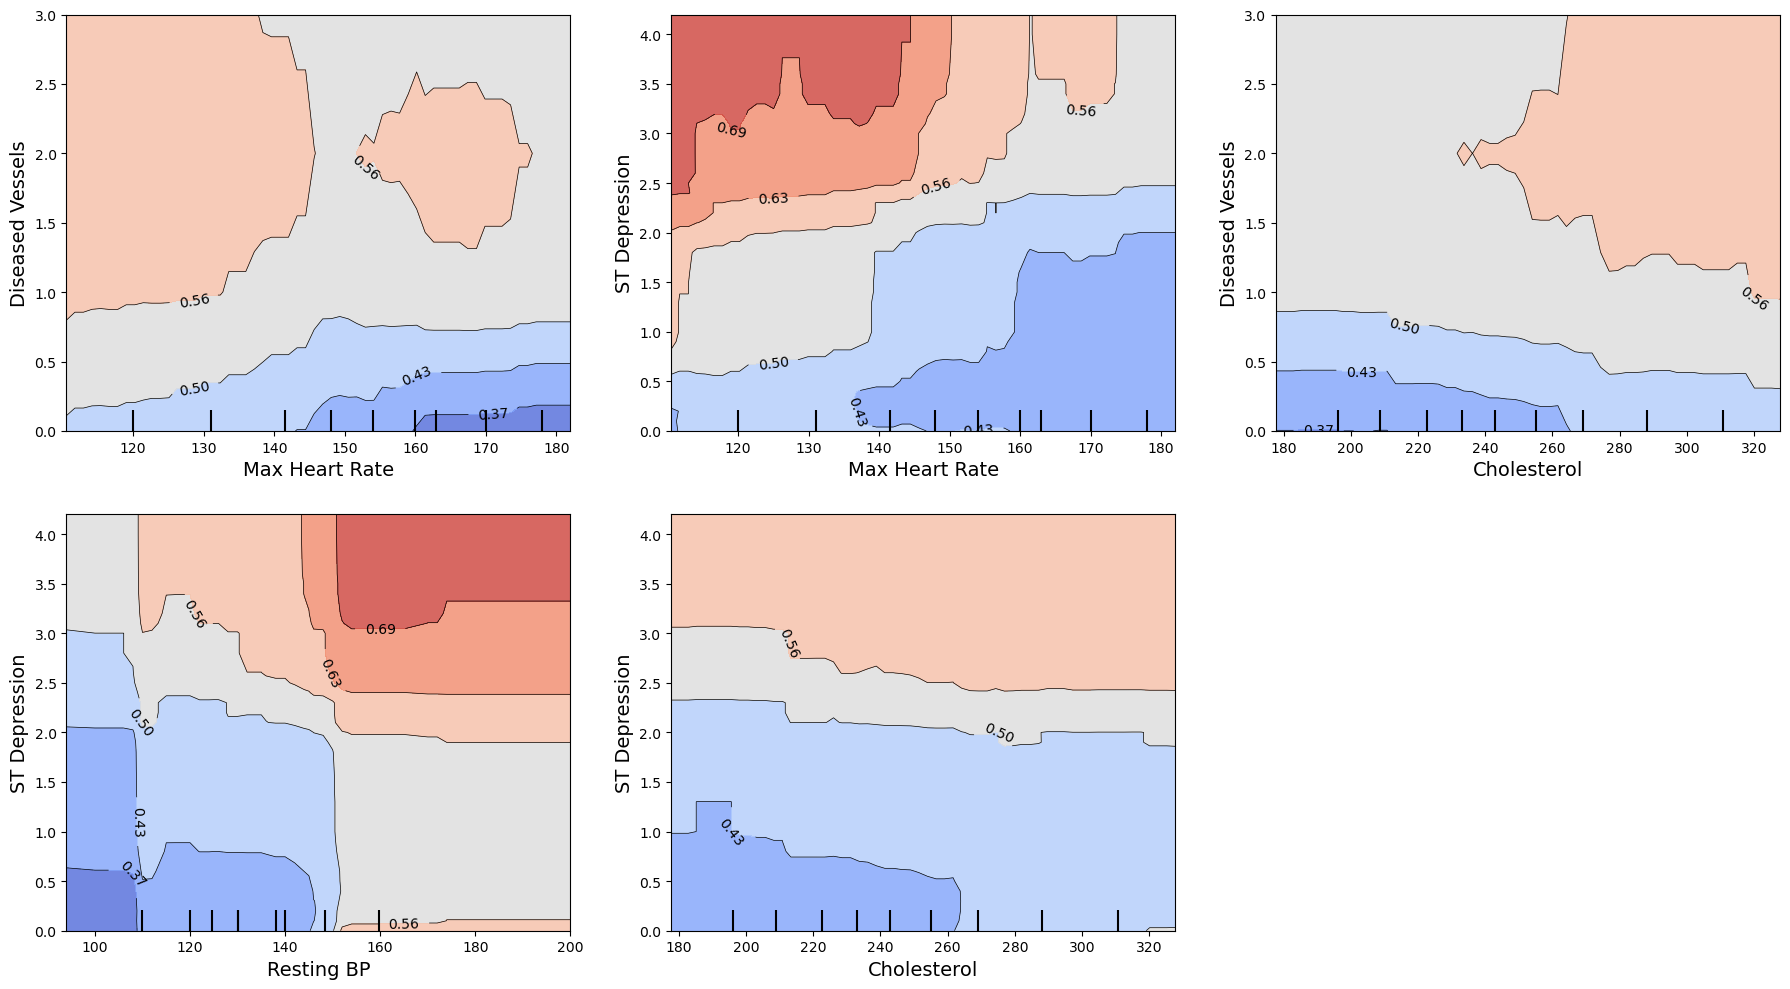

In [23]:
# List of feature pairs to analyze their joint impact on predictions
pairs = [
    ("Max Heart Rate", "Diseased Vessels"),
    ("Max Heart Rate", "ST Depression"),
    ("Cholesterol", "Diseased Vessels"),
    ("Resting BP", "ST Depression"),
    ("Cholesterol", "ST Depression"),
]

# Arrange plots with 3 columns per row
n_cols = 3
n_rows = math.ceil(len(pairs) / n_cols)
fig, ax = plt.subplots(figsize=(18, 5 * n_rows))

# Build 2D Partial Dependence Plots (Contour Heatmaps)
display = PartialDependenceDisplay.from_estimator(
    estimator=model, 
    X=X_train, 
    features=pairs, 
    response_method='predict_proba', 
    grid_resolution=60, # Grid density calculation (60x60 points per plot)
    n_cols=n_cols,
    ax=ax, 
    contour_kw={'cmap': 'coolwarm', 'alpha': 0.8} # Color palette and transparency styling
)

# Increase the font size for axis labels 
for axi in display.axes_.flatten():
    if axi is not None:
        axi.set_xlabel(axi.get_xlabel(), fontsize=14)
        axi.set_ylabel(axi.get_ylabel(), fontsize=14)

plt.tight_layout()
plt.show()

**Max Heart Rate:**

* In conjunction with `Diseased Vessels` and `ST Depression`, a low maximum heart rate under exertion ($<130$ bpm) acts as a potent risk catalyst, triggering the deep-red regions where the predicted probability surges past 0.6.
* The capacity to achieve a high peak heart rate ($>150–160$ bpm) functions as a strong protective factor; the blue regions dominate the right side of the plots, noticeably neutralizing the negative effects of stenosed vessels and mild ischemia.

**ST Depression:**

* In pairs with `Resting BP` and `Cholesterol`, the `ST Depression` feature dictates a sharp risk gradient, with visual stratification running strictly horizontally. Crossing the $1.5–2.0$ mm threshold proves critical.
* Blood pressure ($>140$ mm Hg) and cholesterol ($>260$ mg/dL) act as risk amplifiers; they significantly expand the red high-risk zone downward, rendering even minor ST depression dangerous.

**Diseased Vessels:**

* The interaction with `Cholesterol` reveals a distinct step-like structure. The number of diseased vessels (ranging from 1 to 3) determines the structural baseline of the risk.
* Against the backdrop of existing vascular pathology, an increase in cholesterol beyond $260–28$0 mg/dL acts as a compounding trigger, pushing the probability of pathology onto a maximum plateau.